# Forex Drift Idea — Carry, Intervention & the Trade Balance
### CIB Quant Research · Japan & India case studies + 17-currency panel · data through Sept 2026

**The question.** Interest-rate differentials *should* pin down where exchange rates drift (uncovered interest parity, UIP). But countries often lean against that drift — Japan and the US bought yen in 2024 and 2026, India's RBI spent reserves and subsidised FCNR(B) deposits in 2013 and 2026. Is there a **repeatable, tradable pattern** in *when* currencies deviate from their UIP-implied path, and does a country's **trade position** (net importer vs. exporter) tell us which way policymakers will lean and whether it works?

This notebook is meant to be mined for slides: every figure is also saved as a PNG in `figures/`, and every section ends with a plain-English "what this means" box.

### TL;DR — what the data says (details and caveats below)
1. **UIP fails, as expected, and the failure is our raw material.** Across 17 currencies the "Fama β" is **0.25** (UIP says 1.0). Since 2012 USDJPY has ended **~96% (log) above** the path the rate gap implied; USDINR ended **~5% below** its UIP path, so rupee carry roughly broke even over 14 years.
2. **The team's exact thesis gets mixed-to-negative support in the cross-section.** High-yielding **net importers** are *not* the ones that pay. They track UIP **more** closely (β 0.41 vs −0.20 for exporters; interaction t = 2.0) and earn **less** carry (+0.6% vs +3.0%/yr dollar-neutral) with **much worse crash risk** (skew −1.4 vs −0.4). Central-bank defence doesn't stop net-importer currencies from eventually sliding.
3. **But the trade balance is a genuinely useful *second* signal.** Going long net exporters and short net importers earns **~2%/yr with *positive* skew**, and it holds in both halves of the sample. Its correlation with carry is **−0.32**, and it tends to make money in carry's crash months (8 of carry's 10 worst). A trade balance that is *improving vs. its own 5-year history* works even better (Sharpe 0.52), so it's not just a static country tilt.
4. **Best candidate strategy: a 50/50 blend of carry + trade balance** (strategy C). Net of costs it has **Sharpe 0.73, max drawdown −10%**, Sharpe 0.79 in 2000–12 vs 0.68 in 2013–26, and 0.61–0.79 across 12 recipe variations. Returns are modest unlevered (~2.9%/yr at 4% vol). A G10-only version a retail trader can run with CME futures gets Sharpe ≈ 0.47.
5. **Japan confirms the intuition about *which way* policymakers lean.** Every yen-*selling* intervention (1993–2011) happened while Japan ran trade surpluses; every yen-*buying* one since 2022 happened during trade deficits. But intervention alone doesn't fix the trend: 68% of episodes "worked" at 60 days, the April 2026 one failed, and BoJ hikes weakened the yen on the day in 4 of 6 cases.
6. **India: "managed carry" is real but no longer pays.** The RBI clearly spends reserves against depreciation (corr −0.50). The rupee is the 2nd-least-volatile currency in the panel (6.7% vol), and it fell less than UIP predicted in 17 of 25 years. But the big years (2008, 2011, 2013, 2018, 2022, 2025–26) wiped out the gains: long-INR carry has returned ~0.6%/yr since 2013. **A simple "only hold INR while RBI reserves are rising" filter roughly doubles the Sharpe (0.20 → 0.38) and halves the drawdown.**
7. **2026 is not 2013 (yet).** The 2013 FCNR(B) window marked the rupee's top (−8% during the window, −12% a year later). The 2026 window raised more money ($52bn vs $34bn) but the rupee is **unchanged** (+0.2% during the window). A key difference: in 2013 the Fed *delayed* tapering, while in 2026 the Fed is *hiking*.

### Contents
1. **Setup & data** — sources, coverage, conventions
2. **Primer** — UIP, carry, and the "forward premium puzzle" in one chart
3. **Japan deep dive** — rates vs. yen · trade balance vs. intervention direction · intervention event study · BoJ hikes · valuation · positioning
4. **India deep dive** — UIP by year · managed volatility · RBI reserves · FCNR(B) 2013 vs 2026 · carry P&L
5. **Cross-country panel (17 currencies)** — UIP regressions · carry vs crash risk · **the core trade-balance test** · who defends their currency · signal horse race · crash anatomy
6. **Strategy design & backtests** — candidate strategies, robustness, holdings, single-currency rules, retail implementation
7. **Where things stand now (Sept 2026)** — signal dashboard
8. **Synthesis** — theory scorecard, interpretation, presentation storyline, caveats, next steps, references

### How to read this notebook (neutrality protocol)
The team's starting intuition is that *net importers with high interest rates* (currencies UIP says should depreciate) get defended by their central banks, creating a tradable deviation. To avoid confirmation bias:

* **Every theory is stated up front with what would support it *and* what would refute it**, before the results.
* The **same data and the same test** are applied to all 17 currencies — Japan and India are case studies, not the evidence base.
* Results are shown **raw and dollar-neutral**, **full-sample and split in two halves** (2000–12 / 2013–26), and **with/without outliers** (TRY, BRL).
* Signals are built with **publication lags** (trade data +2 months, reserves +1 month, annual current account from April of the following year), so nothing uses information that wasn't available at the time.
* We tested many variants. The more you try, the more likely something looks good by chance — so treat any single Sharpe ratio skeptically and look for results that are consistent across variants.

Interpretation boxes are marked **🔎 What this means** — those are my reading of the evidence; please challenge them.

---
## 1. Setup & data
All raw data is cached in `data/raw/` by `src/fetch_data.py` (re-run with `--force` to refresh). Helper code lives in `src/fxlib.py` so cells here stay short.

In [1]:
import sys, warnings
sys.path.insert(0, "src"); warnings.filterwarnings("ignore")
import numpy as np, pandas as pd, matplotlib.pyplot as plt, matplotlib.dates as mdates
from matplotlib.colors import LinearSegmentedColormap
import fxlib as fx
from fxlib import BLUE, ORANGE, AQUA, YELLOW, MAGENTA, GREEN, VIOLET, RED, GRAY, LIGHTGRAY, INK, INK2
fx.set_style()
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")
pd.set_option("display.max_columns", 30); pd.set_option("display.width", 220)
DIVERGING = LinearSegmentedColormap.from_list("div", [RED, "#f0efec", BLUE])

P = fx.build_panel()                     # monthly panel, look-ahead-safe lags applied
spot, carry, rx, ds, tb, ca = (P[k] for k in ["spot", "carry", "rx", "ds", "trade", "ca"])
jd = fx.spot_daily("JPY").dropna()        # daily USDJPY
ind = fx.spot_daily("INR").dropna()       # daily USDINR
print(f"Panel: {spot.shape[1]} currencies, {spot.index[0]:%b %Y} to {spot.index[-1]:%b %Y}  "
      f"| daily USDJPY to {jd.index[-1]:%d %b %Y}, USDINR to {ind.index[-1]:%d %b %Y}")

Panel: 17 currencies, Jan 1999 to Sep 2026  | daily USDJPY to 25 Sep 2026, USDINR to 25 Sep 2026


| Data | Source | Frequency | Used for |
|---|---|---|---|
| Spot FX (15 ccys) | Federal Reserve H.10 via FRED (`DEX…`) | daily | returns, event studies |
| Spot FX (TRY, IDR) | Yahoo Finance (bad ticks filtered) | daily | returns |
| Short rates | OECD MEI 3M interbank (`IR3TIB01…`), call-money (`IRSTCI01…`), ECB/SONIA fallbacks | monthly | carry / UIP |
| Merchandise trade | OECD MEI (`XTNTVA01…`, `XTEXVA01…`) | monthly | net importer/exporter |
| Current account | World Bank WDI (`BN.CAB.XOKA.GD.ZS`) | annual | alternative external-balance measure |
| FX reserves ex gold | IMF IFS via FRED (`TRESEG…`) | monthly | "leaning against the wind" |
| Real/nominal effective FX | BIS via FRED (`RB…BIS`, `NB…BIS`) | monthly | valuation |
| Japan intervention | **Japan MoF official daily record 1991–Jun 2026** + monthly releases | daily | event study |
| Speculator positioning | CFTC Commitments of Traders (legacy) | weekly | crowding |
| VIX | CBOE via FRED | daily | risk regime |

*Trade data for EUR ends 2023 and KRW mid-2025 in the OECD feed; those currencies drop out of trade-based signals after that (see table).*

In [2]:
def last(s):
    i = s.last_valid_index(); return "-" if i is None else f"{i:%Y-%m}"
coverage = pd.DataFrame({
    "Group": {c.code: c.group for c in fx.UNIVERSE},
    "FX regime (context only)": {c.code: c.regime for c in fx.UNIVERSE},
    "Spot from": {c: f"{spot[c].first_valid_index():%Y-%m}" for c in spot},
    "Short rate used": {c.code: c.rates[0] for c in fx.UNIVERSE},
    "Rates through": {c: last(P["rate"][c]) for c in spot},
    "Trade data through*": {c: last(tb[c]) for c in spot},
    "FX reserves data": {c.code: "yes" if c.reserves else "-" for c in fx.UNIVERSE},
})
coverage

,Group,FX regime (context only),Spot from,Short rate used,Rates through,Trade data through*,FX reserves data
JPY,G10,"Free float, occasional intervention",1999-01,IR3TIB01JPM156N,2026-09,2026-09,yes
EUR,G10,Free float,1999-01,IR3TIB01EZM156N,2026-09,2023-05,-
GBP,G10,Free float,1999-01,IR3TIB01GBM156N,2026-09,2026-09,yes
CHF,G10,Float; heavy intervention 2011-22,1999-01,IR3TIB01CHM156N,2026-09,2026-09,-
CAD,G10,Free float,1999-01,IR3TIB01CAM156N,2026-09,2026-09,yes
AUD,G10,Free float,1999-01,IR3TIB01AUM156N,2026-09,2026-09,yes
NZD,G10,Free float,1999-01,IR3TIB01NZM156N,2026-09,2026-09,-
NOK,G10,Free float,1999-01,IR3TIB01NOM156N,2026-09,2026-09,-
SEK,G10,Free float,1999-01,IR3TIB01SEM156N,2026-09,2026-09,-
INR,EM,Managed float (heavy smoothing),1999-01,IRSTCI01INM156N,2026-09,2026-09,yes


**Conventions (important — these trip people up):**
* Spot **S = units of foreign currency per 1 USD** (USDJPY = 157, USDINR = 95.8). **S up ⇒ foreign currency weaker.**
* **Carry / rate gap** = foreign short rate − US short rate. JPY carry is negative (Japan's rates are lower); INR carry is positive.
* **Carry-trade excess return** of being *long* the foreign currency, funded in USD, over month *t→t+1*: `rx = gap_t/12 − Δln S_{t+1}`. UIP says **E[rx] = 0**: whatever you earn in interest you lose in depreciation. A "short yen carry trade" is simply `−rx_JPY`.
* We use interbank / call-money rates as a proxy for forward points (covered interest parity). For INR this *understates* the true forward premium when dollar funding is tight — in 2026 banks paid ~280–300bp/yr to hedge USD into INR, versus a ~170bp policy-rate gap.

---
## 2. Primer: what UIP says vs. what happened
**Uncovered interest parity:** `E[ΔlnS] = i_foreign − i_US`. If US rates are 4% and Japan's 0%, investors should *expect* the yen to **appreciate** ~4%/yr — otherwise everyone would borrow yen and buy dollars for free money. In practice, high-rate currencies tend to depreciate **less** than UIP says (or even appreciate). Economists call this the **forward premium puzzle** (Fama 1984), and it is why the **carry trade** has historically paid.

The chart below compounds each month's rate gap from January 2012 to show the path UIP "predicted", and compares it with what actually happened.

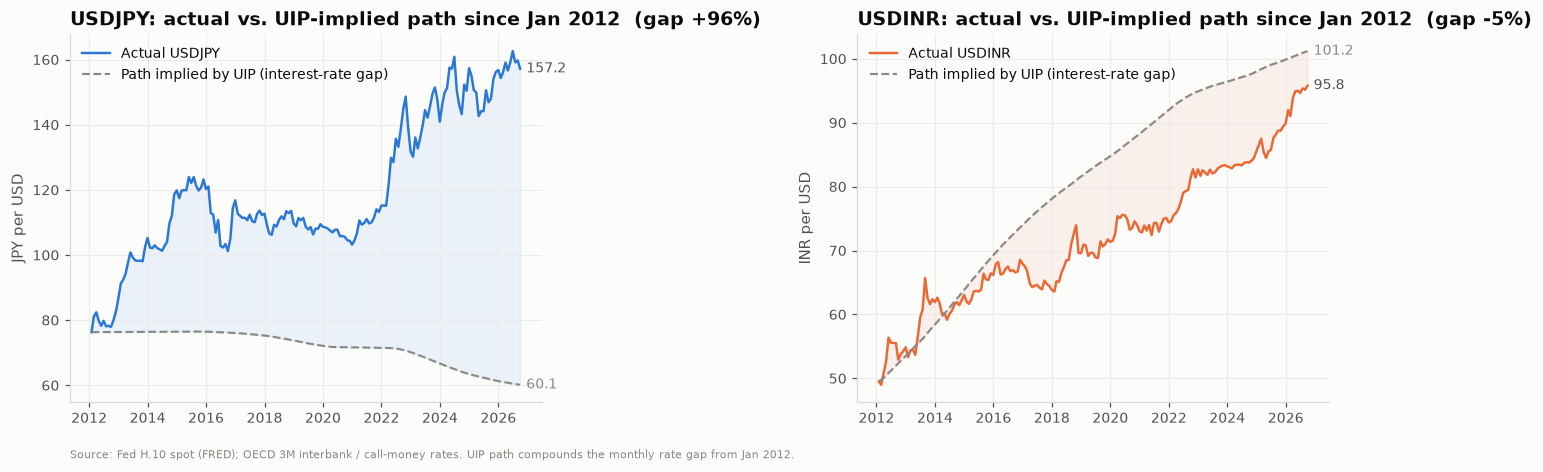

In [3]:
def uip_path(code, start):
    s = spot[code][start:].dropna()
    c = carry[code].reindex(s.index).ffill()
    implied = s.iloc[0] * np.exp((c.shift(1).fillna(0) / 12).cumsum())
    return s, implied

fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.4))
for ax, code in zip(axes, ["JPY", "INR"]):
    s, imp = uip_path(code, "2012-01-31")
    col = fx.CCY_COLOR[code]
    ax.plot(s.index, s, color=col, label=f"Actual USD{code}")
    ax.plot(imp.index, imp, color=GRAY, lw=1.4, ls="--", label="Path implied by UIP (interest-rate gap)")
    ax.fill_between(s.index, s, imp, color=col, alpha=0.08)
    ax.annotate(f"{s.iloc[-1]:.1f}", (s.index[-1], s.iloc[-1]), xytext=(4, 0), textcoords="offset points", color=INK2, fontsize=9, va="center")
    ax.annotate(f"{imp.iloc[-1]:.1f}", (imp.index[-1], imp.iloc[-1]), xytext=(4, 0), textcoords="offset points", color=GRAY, fontsize=9, va="center")
    gap = 100 * np.log(s.iloc[-1] / imp.iloc[-1])
    ax.set_title(f"USD{code}: actual vs. UIP-implied path since Jan 2012  (gap {gap:+.0f}%)")
    ax.set_ylabel(f"{code} per USD"); ax.legend(loc="upper left")
fx.source_note(axes[0], "Source: Fed H.10 spot (FRED); OECD 3M interbank / call-money rates. UIP path compounds the monthly rate gap from Jan 2012.")
fig.tight_layout(); fx.save(fig, "02_uip_vs_actual_jpy_inr"); plt.show()

#### 🔎 What this means

* **Yen:** UIP said the yen should have *strengthened* (from ~76 to ~60 per dollar) because Japan's rates were below America's. It did the opposite, weakening to ~157. That ~96% gap is the profit of the classic "borrow yen, buy dollars" carry trade, and the reason MoF/US Treasury are now intervening.
* **Rupee:** the rupee *did* depreciate, roughly as much as the rate gap predicted. The long-run drift is consistent with UIP; the carry trade's profit is just the small gap between the two lines. What differs from UIP is the *path*: long flat stretches (RBI smoothing) punctuated by sharp jumps (2013, 2018, 2022, 2025–26).
* **Takeaway for the pitch:** "FX drift follows rate gaps" is roughly true for India over long horizons and badly false for Japan. Our strategy has to explain *which* currencies deviate and *when*.

---
## 3. Japan deep dive
Theories tested in this section:

| # | Theory | Would be **supported** if… | Would be **refuted** if… |
|---|---|---|---|
| T1 | A country's trade position predicts **which way** it intervenes | Japan sold yen while a net exporter and bought yen once it became a net importer | Intervention direction unrelated to trade position |
| T3 | Intervention only "sticks" when monetary policy agrees | Episodes where the rate gap subsequently moved MoF's way show lasting moves; others fade | Interventions work (or fail) regardless of policy |
| T6 | Intervention clusters at round-number "lines in the sand" | Operations begin near 145/150/160 etc. | No pattern in trigger levels |
| T7 | The yen is extremely cheap (mean-reversion potential) | Real effective FX at historic lows | — (descriptive) |
| T5 | Crowded short-yen positioning precedes reversals | Most-short positioning quintile is followed by yen strength | No relationship, or the opposite |

### 3.1 The yen and the interest-rate gap

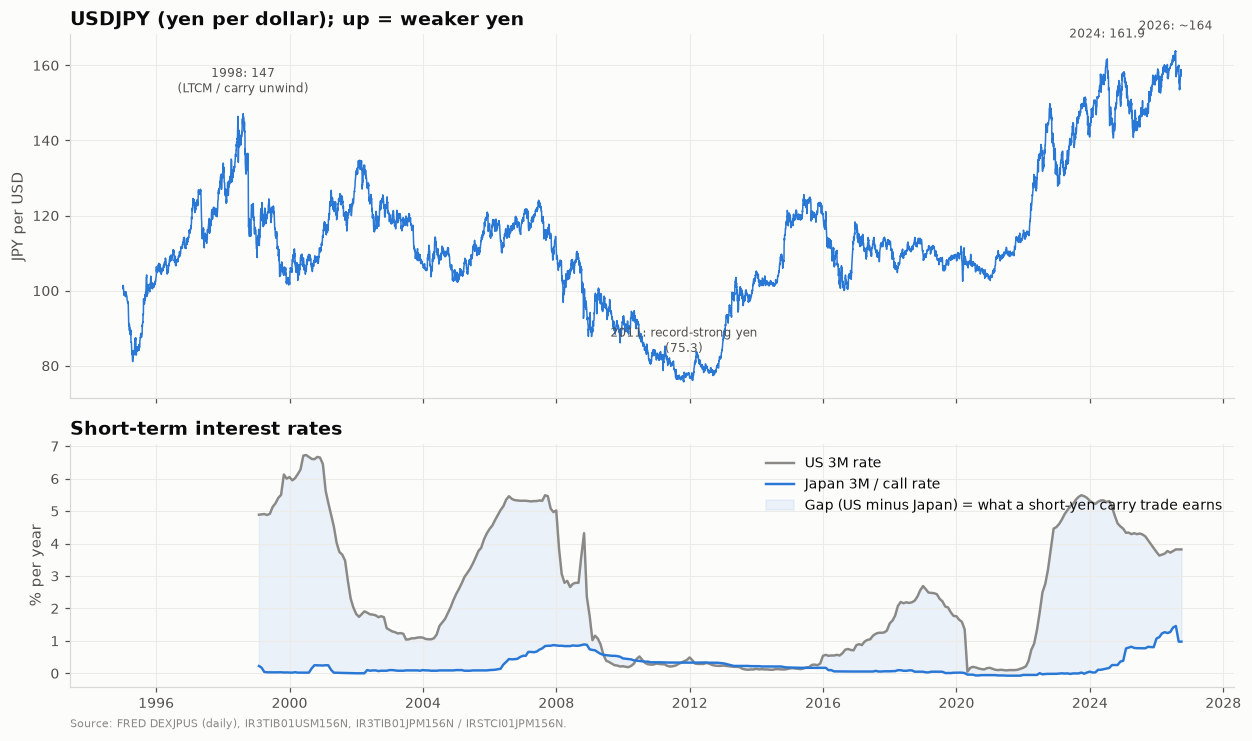

Correlation of 12m change in USDJPY with 12m change in the US-Japan rate gap: 0.23  (1999-2026, overlapping monthly obs)


In [4]:
fig, (a1, a2) = plt.subplots(2, 1, figsize=(11.5, 6.8), sharex=True, gridspec_kw={"height_ratios": [3, 2]})
a1.plot(jd["1995":], color=BLUE, lw=1.0)
a1.set_title("USDJPY (yen per dollar); up = weaker yen"); a1.set_ylabel("JPY per USD")
for d, txt in [("1998-08-11", "1998: 147\n(LTCM / carry unwind)"), ("2011-10-31", "2011: record-strong yen\n(75.3)"),
               ("2024-07-10", "2024: 161.9"), ("2026-07-29", "2026: ~164")]:
    t = jd.index[jd.index.searchsorted(pd.Timestamp(d))]
    a1.annotate(txt, (t, jd[t]), xytext=(0, 14), textcoords="offset points", ha="center", fontsize=8, color=INK2)
us, jp = P["us_rate"], P["rate"]["JPY"]
a2.plot(us["1995":].index, us["1995":], color=GRAY, label="US 3M rate")
a2.plot(jp["1995":].index, jp["1995":], color=BLUE, label="Japan 3M / call rate")
a2.fill_between(us["1995":].index, jp["1995":], us["1995":], color=BLUE, alpha=0.08, label="Gap (US minus Japan) = what a short-yen carry trade earns")
a2.set_ylabel("% per year"); a2.legend(loc="upper right", ncol=1); a2.set_title("Short-term interest rates")
fx.source_note(a2, "Source: FRED DEXJPUS (daily), IR3TIB01USM156N, IR3TIB01JPM156N / IRSTCI01JPM156N.")
fig.tight_layout(); fx.save(fig, "03a_usdjpy_and_rates"); plt.show()

g = (us - jp).dropna(); s12 = 100 * np.log(spot["JPY"]).diff(12)
print("Correlation of 12m change in USDJPY with 12m change in the US-Japan rate gap:",
      f"{s12.corr(g.diff(12)):.2f}  (1999-2026, overlapping monthly obs)")

#### 🔎 What this means

* The yen's big moves line up with the US–Japan rate gap. 1999–2007: wide gap, yen weak. 2008–12: gap collapses to ~0, yen hits a record-strong 75. 2022–26: Fed hikes, gap ~4–5pp, yen weakens past 160. Correlation of 12-month changes is modest (0.23) because a lot of the action is in *levels*.
* This is the **opposite** of UIP. A *wider* gap in the dollar's favour came with a *weaker* yen, when UIP says it should mean yen appreciation ahead. That's the forward premium puzzle in its purest form.
* Implication: as long as the gap stays wide (Fed at 3.75–4.00%, BoJ at 1.25%), the carry motive for shorting yen persists. **A real reversal probably needs the gap to shrink** (Fed cuts or much faster BoJ hikes), not just intervention.

### 3.2 Trade position vs. **direction** of intervention (T1)
Japan is the cleanest natural experiment: it ran trade surpluses for decades, then flipped to persistent deficits after the 2011 earthquake (energy imports) — while keeping a **current-account surplus** thanks to income on its huge overseas investments. If trade position drives policy preferences, the *direction* of intervention should flip too.

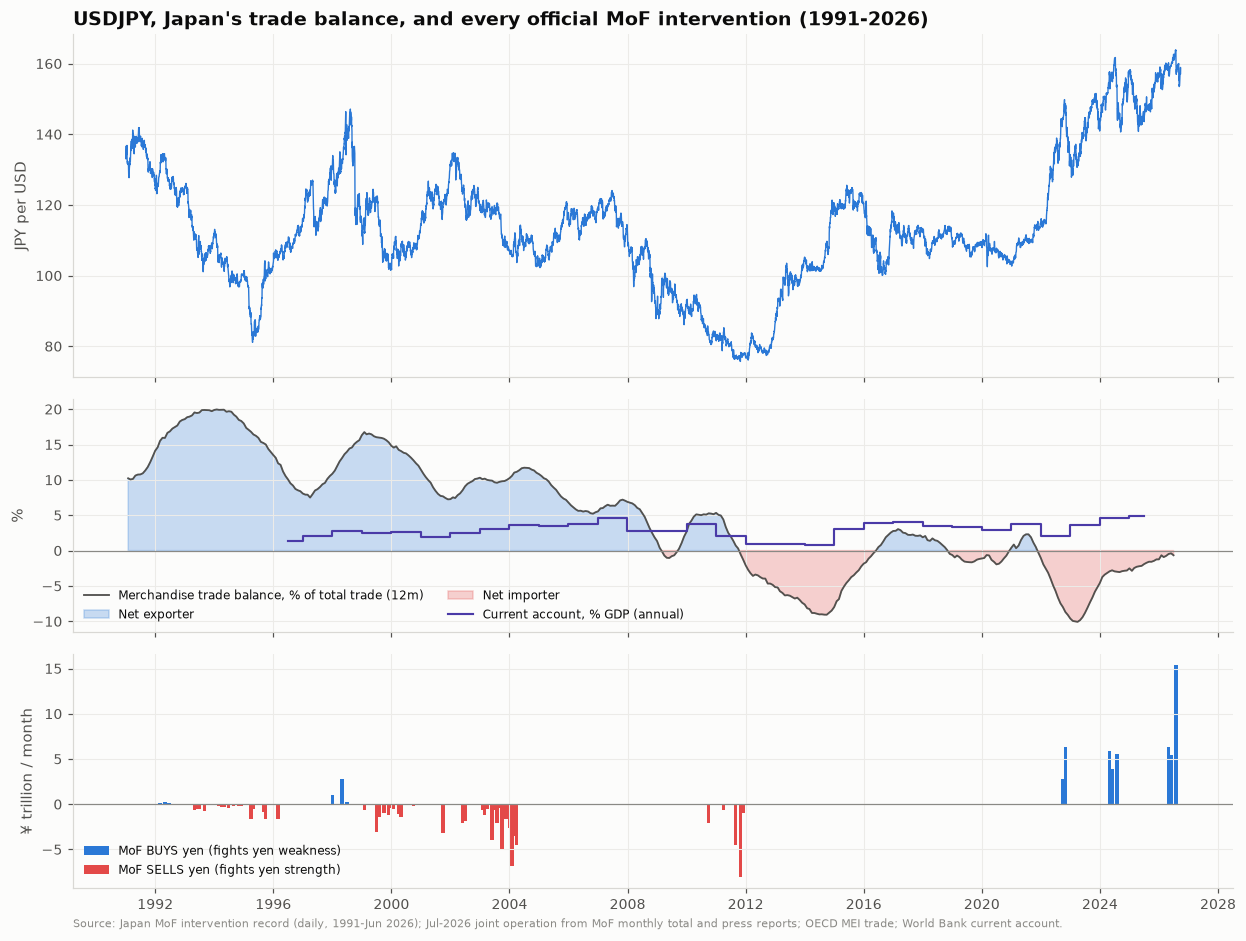

,days,yen_bought_tn,yen_sold_tn,trade bal % (yr avg),current acct % GDP
year,,,,,
1991,3,0.06,-0.00,11.38,NaN
1992,23,0.72,-0.00,16.94,NaN
1993,50,0.00,2.56,19.54,NaN
1994,55,0.00,2.06,19.30,NaN
1995,43,0.00,4.96,15.61,NaN
1996,5,0.00,1.60,10.15,1.37
1997,3,1.06,-0.00,9.00,2.08
1998,3,3.05,-0.00,14.00,2.76
1999,15,0.00,7.64,15.99,2.43


In [5]:
iv = fx.intervention_table()
yen_ops = pd.concat([iv[iv.direction != "non-yen"], fx.REPORTED_2026]).sort_values("date").reset_index(drop=True)
yen_ops["signed_tn"] = np.where(yen_ops.direction == "buy JPY", 1, -1) * yen_ops.yen_tn
ops_m = yen_ops.set_index("date").signed_tn.resample("ME").sum()
jp_tb_raw = fx.trade_ratio("JP")                          # unlagged, for description
jp_ca = fx.wb_annual("current_account_pct_gdp")["JPN"].dropna()

fig, axes = plt.subplots(3, 1, figsize=(11.5, 8.6), sharex=True, gridspec_kw={"height_ratios": [2.2, 1.5, 1.5]})
axes[0].plot(jd["1991":], color=BLUE, lw=0.9); axes[0].set_ylabel("JPY per USD")
axes[0].set_title("USDJPY, Japan's trade balance, and every official MoF intervention (1991-2026)")
x = jp_tb_raw["1991":]
axes[1].plot(x.index, x, color=INK2, lw=1.2, label="Merchandise trade balance, % of total trade (12m)")
axes[1].fill_between(x.index, 0, x, where=x >= 0, color=BLUE, alpha=0.25, label="Net exporter")
axes[1].fill_between(x.index, 0, x, where=x < 0, color=RED, alpha=0.25, label="Net importer")
cai = pd.Series(jp_ca.values, index=pd.to_datetime([f"{y}-07-01" for y in jp_ca.index]))
axes[1].plot(cai["1991":].index, cai["1991":], color=VIOLET, lw=1.4, drawstyle="steps-mid", label="Current account, % GDP (annual)")
axes[1].axhline(0, color=GRAY, lw=0.8); axes[1].set_ylabel("%"); axes[1].legend(loc="lower left", ncol=2, fontsize=8)
o = ops_m["1991":]
axes[2].bar(o.index, o.clip(lower=0), width=40, color=BLUE, label="MoF BUYS yen (fights yen weakness)")
axes[2].bar(o.index, o.clip(upper=0), width=40, color=RED, label="MoF SELLS yen (fights yen strength)")
axes[2].axhline(0, color=GRAY, lw=0.8); axes[2].set_ylabel("¥ trillion / month"); axes[2].legend(loc="lower left", fontsize=8)
fx.source_note(axes[2], "Source: Japan MoF intervention record (daily, 1991-Jun 2026); Jul-2026 joint operation from MoF monthly total and press reports; OECD MEI trade; World Bank current account.")
fig.tight_layout(); fx.save(fig, "03b_japan_trade_vs_intervention_direction"); plt.show()

yr = yen_ops.assign(year=yen_ops.date.dt.year).groupby("year").agg(
    days=("yen_tn", "size"),
    yen_bought_tn=("signed_tn", lambda v: v[v > 0].sum()),
    yen_sold_tn=("signed_tn", lambda v: -v[v < 0].sum()))
yr["trade bal % (yr avg)"] = jp_tb_raw.groupby(jp_tb_raw.index.year).mean().reindex(yr.index)
yr["current acct % GDP"] = jp_ca.reindex(yr.index)
yr

#### 🔎 What this means

* **Direction lines up with the trade position (supports T1 for Japan).** 1993–2011: Japan ran trade surpluses of ~2–20% of trade and **sold** yen in every intervention (¥35tn in 2003–04 alone) to protect exporters. From 2011 Japan's goods trade flipped to deficit, and every intervention since 2022 has been **yen-buying** (¥9tn 2022, ¥15tn 2024, ~¥27tn in 2026 including the reported July joint operation). A weak yen now mainly raises import (energy, food) costs.
* **But it's the *trade* balance, not the *current account*, that lines up.** Japan's current account stayed positive the whole time (2–5% of GDP) because of income on overseas investments. That's worth saying in the pitch: *"net importer"* should mean **goods trade**, which is what drives the domestic political pain of a weak currency.
* **Confounds to be honest about:** (1) The level of the yen matters too. Yen-buying happened when USDJPY was ~128–165, yen-selling below ~125. Weak-yen periods and trade deficits partly go together (energy bills are priced in dollars). (2) 1992 and 1997–98 were yen-buying episodes during surpluses, driven by the Asian crisis and a banking crisis. (3) It's one country. §5.5 checks whether the pattern generalises.

### 3.3 Intervention event study (T3, T6)
For each intervention episode (operations clustered within 45 days), we measure how far USDJPY moved **in the direction the MoF wanted** after 1, 5, 20, 60 and 120 trading days. We also measure the **"policy tailwind"**: whether the US–Japan rate gap moved in MoF's favour over the following 3 months (narrowed when buying yen, widened when selling yen).

*Caveat: the tailwind uses future information — it's a diagnostic of **why** interventions work, not a trading signal by itself. Sample size is small (~25 episodes, most from the 1990s–2000s).*

In [6]:
# Cluster operations into episodes (a new episode starts after a 45-day gap or a direction flip)
ops = yen_ops.copy()
ops["episode"] = ((ops.date.diff().dt.days > 45) | (ops.direction != ops.direction.shift())).cumsum()
ep = ops.groupby("episode").agg(start=("date", "min"), end=("date", "max"), direction=("direction", "first"),
                                days=("date", "size"), size_tn=("yen_tn", "sum")).reset_index(drop=True)

def ev_path(t0, pre=20, post=120):
    i = jd.index.searchsorted(t0); lo = max(0, i - pre)
    seg = jd.iloc[lo:i + post + 1]
    return pd.Series(100 * np.log(seg.values / jd.iloc[i - 1]), index=np.arange(len(seg)) - (i - lo))

gap_m = fx.short_rate(fx.US_RATE) - fx.short_rate(fx.U["JPY"].rates)   # full history back to 1985 (panel starts 1999)
rows, paths = [], {}
for _, e in ep.iterrows():
    # +ve = move in the direction MoF wanted: USDJPY down when buying yen, up when selling yen
    raw = ev_path(e.start); intended = -raw if e.direction == "buy JPY" else raw
    paths[e.start] = intended
    m0 = gap_m.index.searchsorted(e.start) - 1
    dgap = gap_m.iloc[m0 + 3] - gap_m.iloc[m0] if 0 <= m0 and m0 + 3 < len(gap_m) and not np.isnan(gap_m.iloc[m0 + 3]) else np.nan
    rows.append({"start": e.start.date(), "direction": e.direction, "days": e.days, "size ¥tn": e.size_tn,
                 "USDJPY day before": jd.iloc[jd.index.searchsorted(e.start) - 1],
                 **{f"+{h}d %": intended.get(h, np.nan) for h in (1, 5, 20, 60, 120)},
                 "policy tailwind (pp, next 3m)": (-dgap if e.direction == "buy JPY" else dgap)})
evt = pd.DataFrame(rows)
print("Event study: % move in the direction the MoF WANTED (positive = intervention 'worked'), measured from the close before day 0")
evt

Event study: % move in the direction the MoF WANTED (positive = intervention 'worked'), measured from the close before day 0


,start,direction,days,size ¥tn,USDJPY day before,+1d %,+5d %,+20d %,+60d %,+120d %,"policy tailwind (pp, next 3m)"
0,1991-05-13,buy JPY,3,0.06,138.75,0.43,0.38,-1.75,2.11,6.28,-0.69
1,1992-01-17,buy JPY,23,0.72,128.28,4.04,2.27,0.22,-3.46,2.71,-0.44
2,1993-04-02,sell JPY,50,2.56,114.10,-0.44,-0.79,-2.51,-7.32,-6.89,0.13
3,1994-02-15,sell JPY,25,0.91,104.08,-0.27,1.64,1.69,0.33,-3.63,1.02
4,1994-06-20,sell JPY,30,1.16,102.75,-0.95,-2.66,-3.52,-3.67,-2.67,0.26
5,1995-02-17,sell JPY,43,4.96,97.55,-0.26,-0.82,-8.70,-11.61,-6.33,0.60
6,1996-02-20,sell JPY,5,1.60,105.35,-0.09,-0.93,0.86,0.43,2.61,-0.05
7,1997-12-17,buy JPY,3,1.06,130.87,1.80,0.62,1.53,1.12,-7.82,0.14
8,1998-04-09,buy JPY,2,2.82,132.64,2.81,0.65,-0.34,-4.94,-2.28,-0.01
9,1998-06-17,buy JPY,1,0.23,144.05,4.57,2.32,2.37,6.99,18.64,0.01


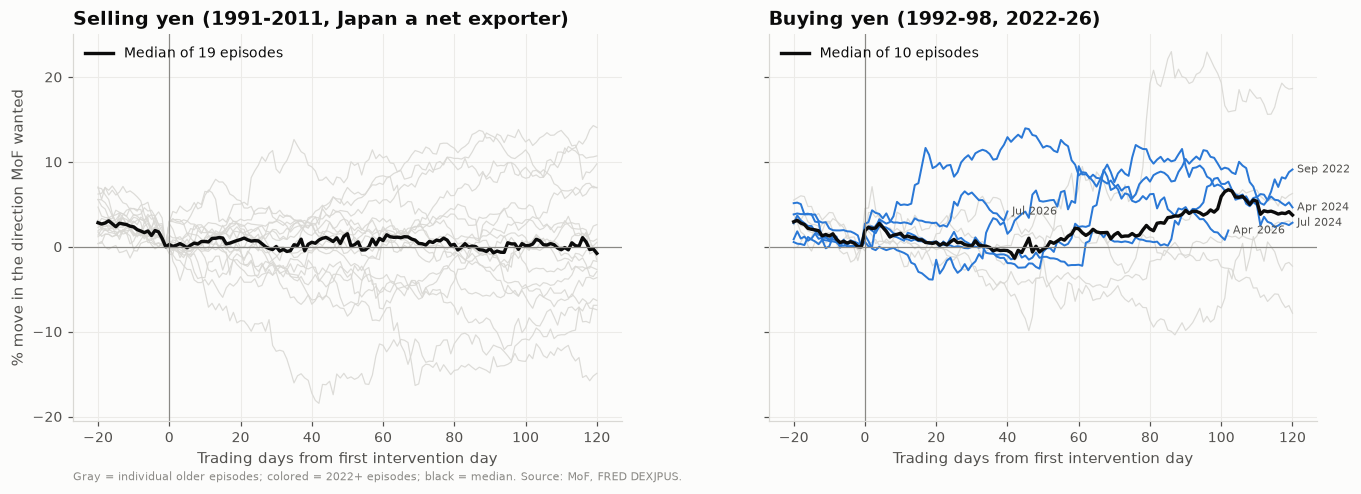

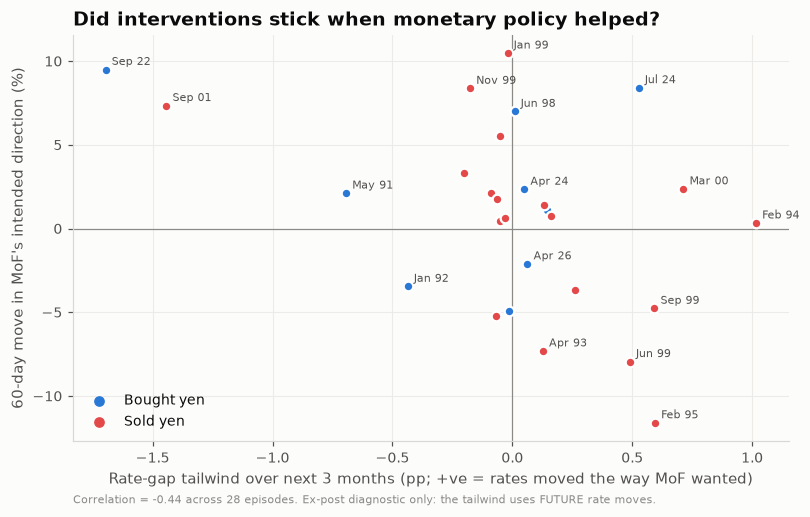

Share of episodes with a positive +60d move: 68%;  with tailwind>0: 57%  vs  tailwind<=0: 79%


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.6), sharey=True)
for ax, dirn, col, title in [(axes[0], "sell JPY", RED, "Selling yen (1991-2011, Japan a net exporter)"),
                              (axes[1], "buy JPY", BLUE, "Buying yen (1992-98, 2022-26)")]:
    starts = ep[ep.direction == dirn].start
    mat = pd.DataFrame({s: paths[s] for s in starts})
    for s in starts:
        recent = s.year >= 2022
        ax.plot(mat.index, mat[s], color=col if recent else LIGHTGRAY, lw=1.3 if recent else 0.8, alpha=1 if recent else 0.9)
        if recent:
            v = mat[s].dropna(); ax.annotate(f"{s:%b %Y}", (v.index[-1], v.iloc[-1]), xytext=(3, 0), textcoords="offset points", fontsize=7.5, color=INK2, va="center")
    ax.plot(mat.index, mat.median(axis=1), color=INK, lw=2.2, label=f"Median of {len(starts)} episodes")
    ax.axhline(0, color=GRAY, lw=0.8); ax.axvline(0, color=GRAY, lw=0.8)
    ax.set_title(title); ax.set_xlabel("Trading days from first intervention day"); ax.legend(loc="upper left")
axes[0].set_ylabel("% move in the direction MoF wanted")
fx.source_note(axes[0], "Gray = individual older episodes; colored = 2022+ episodes; black = median. Source: MoF, FRED DEXJPUS.")
fig.tight_layout(); fx.save(fig, "03c_intervention_event_study"); plt.show()

e2 = evt.dropna(subset=["+60d %", "policy tailwind (pp, next 3m)"])
fig, ax = plt.subplots(figsize=(7.5, 4.8))
for _, r in e2.iterrows():
    c = BLUE if r.direction == "buy JPY" else RED
    ax.scatter(r["policy tailwind (pp, next 3m)"], r["+60d %"], s=40, color=c, edgecolor="white", linewidth=1.5, zorder=3)
    if r.start.year >= 2022 or abs(r["+60d %"]) > 6 or abs(r["policy tailwind (pp, next 3m)"]) > 0.4:
        ax.annotate(f"{r.start:%b %y}", (r["policy tailwind (pp, next 3m)"], r["+60d %"]), xytext=(4, 3), textcoords="offset points", fontsize=7.5, color=INK2)
ax.axhline(0, color=GRAY, lw=0.8); ax.axvline(0, color=GRAY, lw=0.8)
ax.set_xlabel("Rate-gap tailwind over next 3 months (pp; +ve = rates moved the way MoF wanted)")
ax.set_ylabel("60-day move in MoF's intended direction (%)")
ax.set_title("Did interventions stick when monetary policy helped?")
ax.scatter([], [], color=BLUE, label="Bought yen"); ax.scatter([], [], color=RED, label="Sold yen"); ax.legend(loc="lower left")
c = e2["policy tailwind (pp, next 3m)"].corr(e2["+60d %"])
fx.source_note(ax, f"Correlation = {c:.2f} across {len(e2)} episodes. Ex-post diagnostic only: the tailwind uses FUTURE rate moves.")
fig.tight_layout(); fx.save(fig, "03d_intervention_vs_policy_tailwind"); plt.show()
print(f"Share of episodes with a positive +60d move: {(e2['+60d %']>0).mean():.0%};  "
      f"with tailwind>0: {(e2.loc[e2['policy tailwind (pp, next 3m)']>0,'+60d %']>0).mean():.0%}  vs  tailwind<=0: {(e2.loc[e2['policy tailwind (pp, next 3m)']<=0,'+60d %']>0).mean():.0%}")

#### 🔎 What this means

* **Short-term, interventions "work".** Modern yen-buying operations move USDJPY 2–3% in the intended direction within 1–5 days. **68% of episodes** were still in the intended direction after 60 trading days, and all three of 2022–24 were (+9.5%, +2.3%, +8.4%).
* **But not always:** the **April–May 2026** operation (¥11.7tn at ~160) was fully reversed within 60 days (−2.1%). The yen went on to ~164, which triggered the larger **joint US–Japan** operation on 30–31 July 2026 (+2.9% at 20 days so far).
* **T3 ("it sticks only if policy helps") is *not* supported** by this crude test. The correlation between later rate-gap moves and 60-day success is **negative** (−0.44). Episodes with a policy tailwind succeeded 57% of the time vs. 79% without. This is probably confounded: panics like Sept 2001 and Sept 2022 bring both big FX reversals *and* policy moves the "wrong" way. With ~28 episodes, mostly from the 1990s, I wouldn't lean on it either way.
* **T6 (round-number lines):** trigger levels **drift upward** each cycle: ~145 (1998, 2022) → ~158–162 (2024) → ~160–164 (2026). There is no fixed line. The more useful rule is *"MoF acts after a fast move to a new multi-decade high"*, which is when a short-yen position is most exposed to a sudden 2–5% drop.
* **Tradable read:** intervention is a **risk to manage** for short-yen positions (see the "pause after intervention" rule in §6.3), not an alpha signal by itself.

### 3.4 2025–26 close-up: rate hikes that *weakened* the yen
The slides note the yen **fell ~0.5%** after the BoJ's 18 Sept 2026 hike to 1.25%. Is that a one-off or a pattern? If markets price hikes in advance, and the hikes are smaller than the Fed's moves, "buy the rumour, sell the fact" is plausible.

USDJPY % change after each BoJ hike (positive = yen WEAKENED despite the hike). Day 0 = Fed H.10 noon-NY fix on decision day.


,BoJ hike,new rate,USDJPY before,+0d %,+5d %,+20d %,+60d %
0,2024-03-19,end of negative rates (0-0.1%),149.13,1.07,1.63,3.58,4.43
1,2024-07-31,0.25%,153.72,-2.20,-4.18,-6.21,-1.07
2,2025-01-24,0.50%,156.00,-0.27,-0.70,-4.21,-10.24
3,2025-12-19,0.75%,155.53,1.21,0.37,1.68,1.70
4,2026-06-16,1.00%,160.20,0.12,0.97,1.38,-4.14
5,2026-09-18,1.25%,155.85,0.65,0.85,NaN,NaN


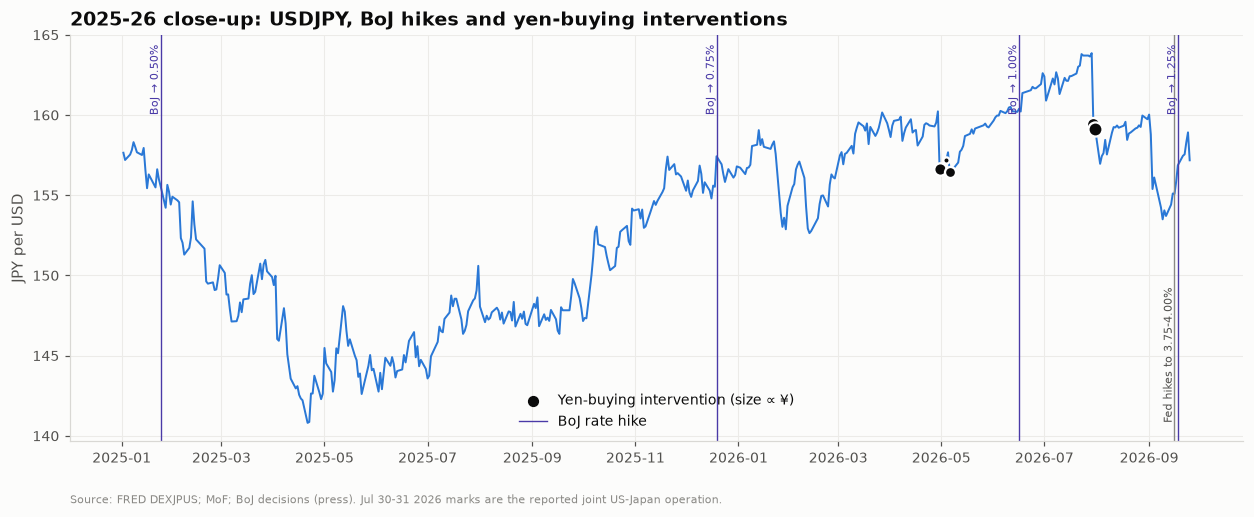

In [8]:
hikes = {"2024-03-19": "end of negative rates (0-0.1%)", "2024-07-31": "0.25%", "2025-01-24": "0.50%",
         "2025-12-19": "0.75%", "2026-06-16": "1.00%", "2026-09-18": "1.25%"}
rows = []
for d, lvl in hikes.items():
    i = jd.index.searchsorted(pd.Timestamp(d)); b = jd.iloc[i - 1]
    rows.append({"BoJ hike": d, "new rate": lvl, "USDJPY before": b,
                 **{f"+{h}d %": (100 * np.log(jd.iloc[i + h] / b) if i + h < len(jd) else np.nan) for h in (0, 5, 20, 60)}})
bojt = pd.DataFrame(rows)
print("USDJPY % change after each BoJ hike (positive = yen WEAKENED despite the hike). Day 0 = Fed H.10 noon-NY fix on decision day.")
display(bojt)

z = jd["2025-01-01":]
fig, ax = plt.subplots(figsize=(11.5, 4.8))
ax.plot(z.index, z, color=BLUE, lw=1.3)
for d, lvl in hikes.items():
    t = pd.Timestamp(d)
    if t >= z.index[0]:
        ax.axvline(t, color=VIOLET, lw=0.9); ax.annotate(f"BoJ → {lvl}", (t, z.max() + 0.5), rotation=90, fontsize=7.5, color=VIOLET, ha="right", va="top")
for _, o in yen_ops[yen_ops.date >= "2025-01-01"].iterrows():
    t = jd.index[min(jd.index.searchsorted(o.date), len(jd) - 1)]
    ax.scatter(t, jd[t], s=10 + 9 * o.yen_tn, color=INK, edgecolor="white", linewidth=1.5, zorder=4)
ax.scatter([], [], color=INK, s=40, label="Yen-buying intervention (size ∝ ¥)"); ax.plot([], [], color=VIOLET, lw=0.9, label="BoJ rate hike")
ax.axvline(pd.Timestamp("2026-09-16"), color=GRAY, lw=0.9); ax.annotate("Fed hikes to 3.75-4.00%", (pd.Timestamp("2026-09-16"), z.min()), rotation=90, fontsize=7.5, color=INK2, ha="right", va="bottom")
ax.legend(loc="lower center"); ax.set_ylabel("JPY per USD"); ax.set_title("2025-26 close-up: USDJPY, BoJ hikes and yen-buying interventions")
fx.source_note(ax, "Source: FRED DEXJPUS; MoF; BoJ decisions (press). Jul 30-31 2026 marks are the reported joint US-Japan operation.")
fig.tight_layout(); fx.save(fig, "03e_2025_2026_closeup"); plt.show()

#### 🔎 What this means

* The slide's observation generalises: **in 4 of the 6 BoJ hikes since 2024 the yen *weakened* on the day** (Mar 2024, Dec 2025, Jun 2026, Sep 2026). Hikes were well telegraphed and small relative to the US–Japan gap, and the guidance was often read as dovish ("buy the rumour, sell the fact").
* The two exceptions matter. **July 2024** (−2.2% on the day, −6.2% after 20 days) coincided with a weak US jobs report and the **August 2024 carry unwind**. **January 2025** was followed by a −10% move over 60 days. A BoJ hike moves the yen a lot only when it lines up with a *US* shock that squeezes the gap from both sides.
* Practical point for the presentation: BoJ hikes alone haven't been a good reason to cover a short-yen position.

### 3.5 Valuation: how cheap is the yen? (T7)

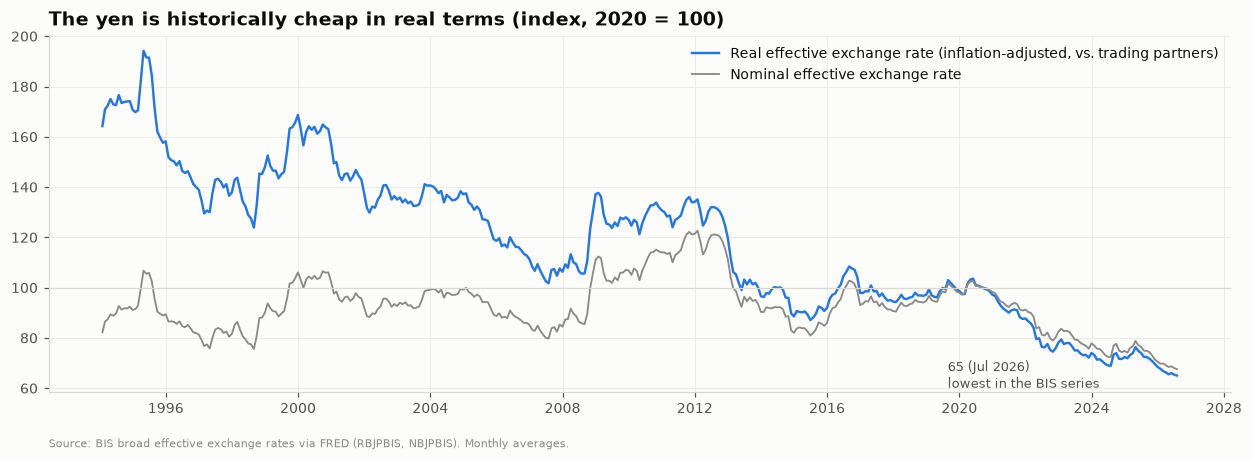

Current REER percentile vs. 1994-today: 0.3%


In [9]:
reer = fx.monthly_last(fx.fred("RBJPBIS")); neer = fx.monthly_last(fx.fred("NBJPBIS"))
fig, ax = plt.subplots(figsize=(11.5, 4.3))
ax.plot(reer.index, reer, color=BLUE, label="Real effective exchange rate (inflation-adjusted, vs. trading partners)")
ax.plot(neer.index, neer, color=GRAY, lw=1.2, label="Nominal effective exchange rate")
ax.axhline(100, color=LIGHTGRAY, lw=0.8)
ax.annotate(f"{reer.iloc[-1]:.0f} ({reer.index[-1]:%b %Y})\nlowest in the BIS series", (reer.index[-1], reer.iloc[-1]), xytext=(-150, -8), textcoords="offset points", fontsize=8.5, color=INK2)
ax.set_title("The yen is historically cheap in real terms (index, 2020 = 100)"); ax.legend(loc="upper right")
fx.source_note(ax, "Source: BIS broad effective exchange rates via FRED (RBJPBIS, NBJPBIS). Monthly averages.")
fig.tight_layout(); fx.save(fig, "03f_jpy_reer"); plt.show()
print(f"Current REER percentile vs. 1994-today: {(reer <= reer.iloc[-1]).mean():.1%}")

#### 🔎 What this means

* In real (inflation-adjusted, trade-weighted) terms the yen is at the **very bottom of the BIS series** (0.3rd percentile since 1994), about **54% below** its 1994–2007 average.
* Cheapness is a **slow** force. §5.6 shows a REER-value signal had essentially no predictive power at one-month horizons in our panel. The yen has been "cheap" for four years and got cheaper. Treat this as the reason the *eventual* reversal could be large, not as a timing tool.

### 3.6 Crowding: speculator positioning in yen futures (T5)

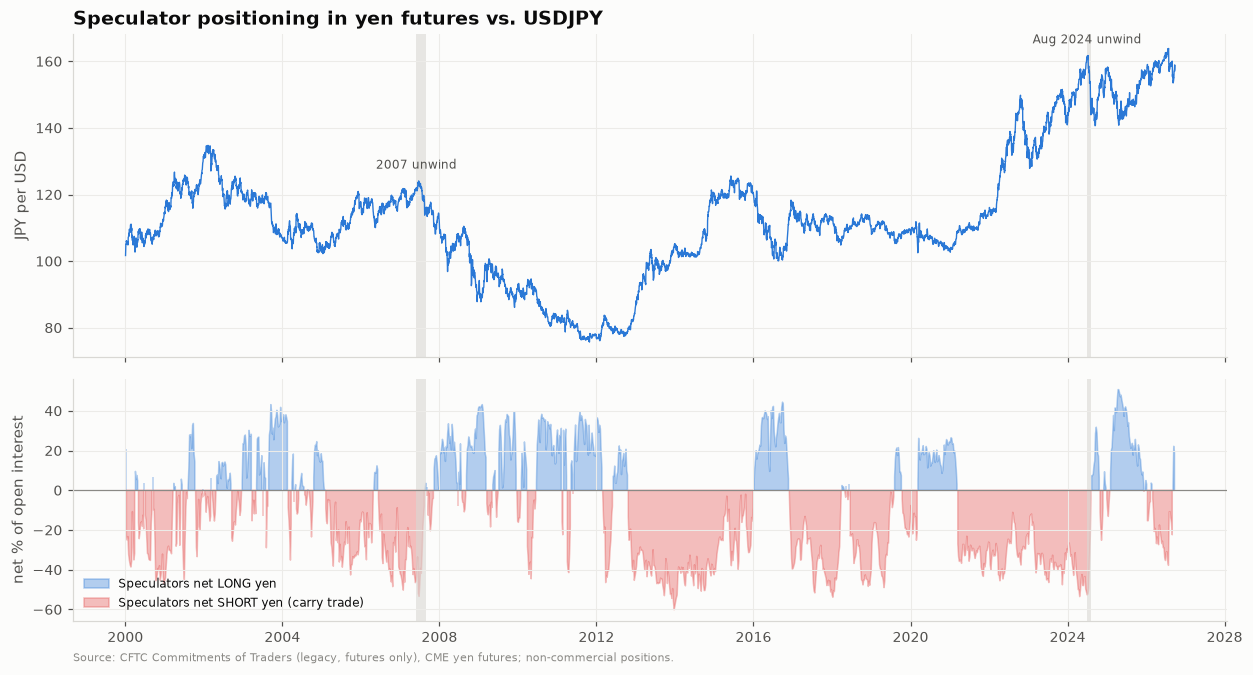

Average NEXT-period yen move (positive = yen strengthened) by speculator-positioning quintile, 2000-2026


,positioning,next 1m JPY spot %,next 3m JPY spot %,months
positioning,,,,
Q1 most short,-43.53,-0.24,-0.77,64
Q2,-31.25,-0.60,-1.85,63
Q3,-15.01,0.03,0.45,64
Q4,6.95,0.49,1.05,63
Q5 most long,30.01,-0.29,-0.76,64


In [10]:
cot = pd.read_csv("data/raw/cftc_currency_cot.csv", parse_dates=["date"])
cot["net_pct_oi"] = 100 * (cot.nc_long - cot.nc_short) / cot.oi
pos_w = cot.pivot(index="date", columns="ccy", values="net_pct_oi")
pos = pos_w.resample("ME").last().reindex(spot.index)

fig, (a1, a2) = plt.subplots(2, 1, figsize=(11.5, 6.2), sharex=True, gridspec_kw={"height_ratios": [2, 1.5]})
a1.plot(jd["2000":], color=BLUE, lw=0.9); a1.set_ylabel("JPY per USD"); a1.set_title("Speculator positioning in yen futures vs. USDJPY")
pj = pos_w["JPY"]
a2.fill_between(pj.index, 0, pj, where=pj >= 0, color=BLUE, alpha=0.35, label="Speculators net LONG yen")
a2.fill_between(pj.index, 0, pj, where=pj < 0, color=RED, alpha=0.35, label="Speculators net SHORT yen (carry trade)")
a2.axhline(0, color=GRAY, lw=0.8); a2.set_ylabel("net % of open interest"); a2.legend(loc="lower left", fontsize=8)
for d0, d1, lbl in [("2007-06-01", "2007-08-31", "2007"), ("2024-07-01", "2024-08-10", "Aug 2024")]:
    for a in (a1, a2): a.axvspan(pd.Timestamp(d0), pd.Timestamp(d1), color=LIGHTGRAY, alpha=0.6, lw=0)
    a1.annotate(f"{lbl} unwind", (pd.Timestamp(d0), jd[d0:d1].max()), xytext=(0, 8), textcoords="offset points", fontsize=8, color=INK2, ha="center")
fx.source_note(a2, "Source: CFTC Commitments of Traders (legacy, futures only), CME yen futures; non-commercial positions.")
fig.tight_layout(); fx.save(fig, "03g_jpy_positioning"); plt.show()

d = pd.DataFrame({"positioning": pos["JPY"], "next 1m JPY spot %": 100 * -ds["JPY"].shift(-1),
                  "next 3m JPY spot %": 100 * -np.log(spot["JPY"]).diff(3).shift(-3)}).dropna()
tbl = d.groupby(pd.qcut(d.positioning, 5, labels=["Q1 most short", "Q2", "Q3", "Q4", "Q5 most long"])).mean()
tbl["months"] = d.groupby(pd.qcut(d.positioning, 5)).size().values
print("Average NEXT-period yen move (positive = yen strengthened) by speculator-positioning quintile, 2000-2026")
tbl

#### 🔎 What this means

* Speculators were heavily net short yen before the 2007 and August 2024 unwinds, and those unwinds were violent (USDJPY −12% from July to August 2024).
* **But extreme positioning is not a reliable contrarian signal (T5 not supported).** The most-short quintile was followed by *further* yen weakness on average (−0.24%/1m, −0.77%/3m), not a reversal. Crowding tells you the **size** of the move when a trigger arrives, not **when**.
* **Notable right now:** positioning swung from **−36% of open interest (late July 2026)** to **net long +19–22%** in mid-September. Speculative yen longs doubled in the week of the Fed hike (16 Sept) and BoJ hike (18 Sept). The crowded short that fuelled the 2024 unwind is not there today.

---
## 4. India deep dive
India is the team's "net importer with a higher interest rate" archetype: persistent trade deficits (oil ≈ 89% imported), policy rates above the US, and a central bank known for smoothing the rupee.

| # | Theory | Supported if… | Refuted if… |
|---|---|---|---|
| T2 | **Managed carry** — RBI smoothing makes INR carry "up the stairs, down the elevator": steady gains, rare sharp losses | Low vol, positive carry return, negative skew, losses concentrated in stress episodes | INR moves like any free-floating EM currency |
| T1b | Net importers defend **against depreciation** more than they resist appreciation | Reserves fall sharply when INR weakens, rise less when it strengthens | Symmetric or no reserve response |
| T8 | The **FCNR(B) swap window** is a reliable turning point for the rupee (2013 precedent) | Rupee recovered strongly after both 2013 and 2026 windows opened | 2026 doesn't repeat 2013 |
| — | "INR normally depreciates ~4%/yr" (slide 11) | Long-run average close to 4% and close to the rate gap | Materially different |

### 4.1 The rupee's path, and UIP year by year

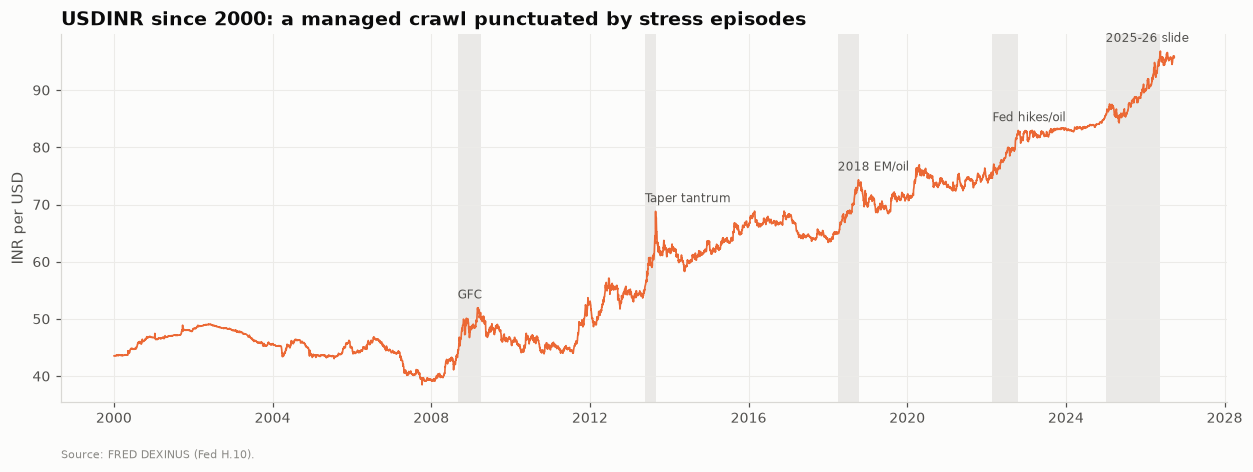

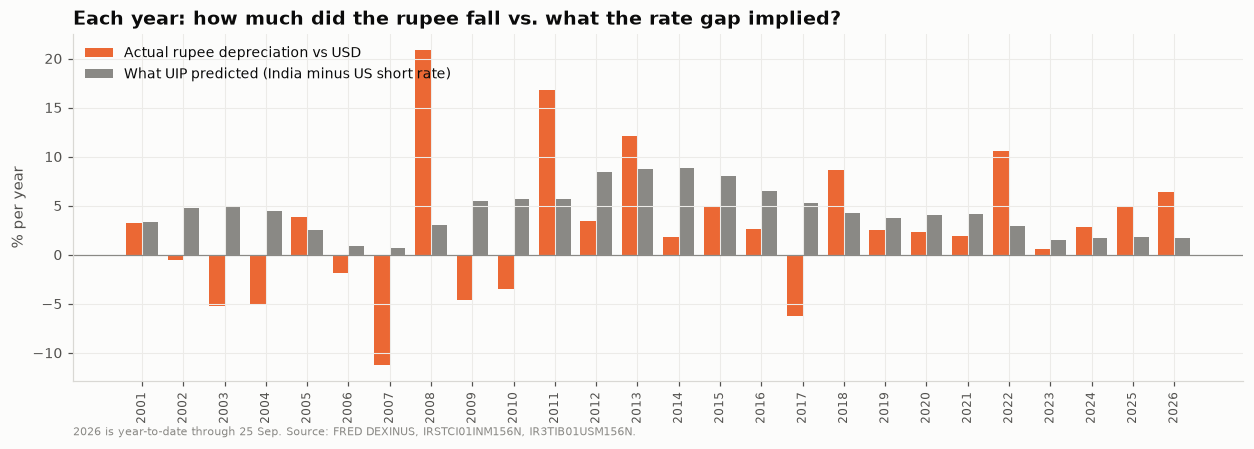

2001-2025 average: actual depreciation 2.61%/yr, UIP-implied 4.46%/yr, median actual 2.53%; years actual < UIP: 17 of 25


,2001,2002,2003,2004,2005,2006,2007,2008,2009,2010,2011,2012,2013,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024,2025,2026
Rupee depreciation % (actual),3.20,-0.56,-5.24,-5.14,3.81,-1.89,-11.27,20.92,-4.59,-3.51,16.83,3.43,12.11,1.79,4.88,2.58,-6.21,8.63,2.53,2.29,1.87,10.61,0.57,2.80,4.89,6.43
UIP-predicted depreciation % (= rate gap),3.31,4.73,4.93,4.44,2.49,0.85,0.73,3.04,5.44,5.69,5.70,8.43,8.78,8.86,8.05,6.49,5.31,4.31,3.78,4.08,4.14,2.94,1.55,1.70,1.85,1.76
Actual minus UIP,-0.11,-5.29,-10.17,-9.57,1.32,-2.73,-12.00,17.88,-10.04,-9.20,11.13,-5.00,3.32,-7.07,-3.18,-3.91,-11.52,4.32,-1.26,-1.80,-2.26,7.68,-0.98,1.10,3.04,4.68


In [11]:
fig, ax = plt.subplots(figsize=(11.5, 4.4))
z = ind["2000":]
ax.plot(z.index, z, color=ORANGE, lw=1.1)
for d0, d1, lbl in [("2008-09-01", "2009-03-31", "GFC"), ("2013-05-22", "2013-09-04", "Taper tantrum"),
                    ("2018-04-01", "2018-10-15", "2018 EM/oil"), ("2022-02-24", "2022-10-20", "Fed hikes/oil"),
                    ("2025-01-01", "2026-05-20", "2025-26 slide")]:
    ax.axvspan(pd.Timestamp(d0), pd.Timestamp(d1), color=LIGHTGRAY, alpha=0.5, lw=0)
    ax.annotate(lbl, (pd.Timestamp(d0), z[d0:d1].max()), xytext=(0, 6), textcoords="offset points", fontsize=8, color=INK2)
ax.set_ylabel("INR per USD"); ax.set_title("USDINR since 2000: a managed crawl punctuated by stress episodes")
fx.source_note(ax, "Source: FRED DEXINUS (Fed H.10).")
fig.tight_layout(); fx.save(fig, "04a_usdinr_history"); plt.show()

yr_dep = 100 * np.log(ind.resample("YE").last()).diff()
yr_gap = (P["rate"]["INR"] - P["us_rate"]).resample("YE").mean()
yrs = pd.DataFrame({"Rupee depreciation % (actual)": yr_dep, "UIP-predicted depreciation % (= rate gap)": yr_gap}).loc["2001":]
yrs.index = yrs.index.year
yrs["Actual minus UIP"] = yrs.iloc[:, 0] - yrs.iloc[:, 1]
fig, ax = plt.subplots(figsize=(11.5, 4.2))
x = np.arange(len(yrs)); w = 0.38
ax.bar(x - w / 2, yrs.iloc[:, 0], width=w, color=ORANGE, label="Actual rupee depreciation vs USD")
ax.bar(x + w / 2, yrs.iloc[:, 1], width=w, color=GRAY, label="What UIP predicted (India minus US short rate)")
ax.set_xticks(x); ax.set_xticklabels(yrs.index, rotation=90, fontsize=8); ax.axhline(0, color=GRAY, lw=0.8)
ax.set_ylabel("% per year"); ax.legend(loc="upper left"); ax.set_title("Each year: how much did the rupee fall vs. what the rate gap implied?")
fx.source_note(ax, f"2026 is year-to-date through {ind.index[-1]:%d %b}. Source: FRED DEXINUS, IRSTCI01INM156N, IR3TIB01USM156N.")
fig.tight_layout(); fx.save(fig, "04b_inr_actual_vs_uip_by_year"); plt.show()
full = yrs.loc[2001:2025]
print(f"2001-2025 average: actual depreciation {full.iloc[:,0].mean():.2f}%/yr, UIP-implied {full.iloc[:,1].mean():.2f}%/yr, "
      f"median actual {full.iloc[:,0].median():.2f}%; years actual < UIP: {(full['Actual minus UIP']<0).sum()} of {len(full)}")
yrs.round(2).T

#### 🔎 What this means

* **The "INR depreciates ~4%/yr" rule of thumb (slide 11) is too high.** 2001–2025 the rupee fell **2.6%/yr on average** (median 2.5%), while the rate gap implied **4.5%/yr**. The rupee depreciated **less than UIP predicted in 17 of 25 years**, and that is the carry profit.
* The losses cluster: **2008 (+21%), 2011 (+17%), 2013 (+12%), 2018 (+9%), 2022 (+11%)**, and now **2025 (+4.9%) and 2026 YTD (+6.4%, 90.2 → 95.8)**. The last two are well above the ~1.8% gap, which has shrunk as US rates rose. So INR carry currently pays little and the rupee is falling faster than UIP. That is the "elevator" phase.

### 4.2 Managed volatility (T2)

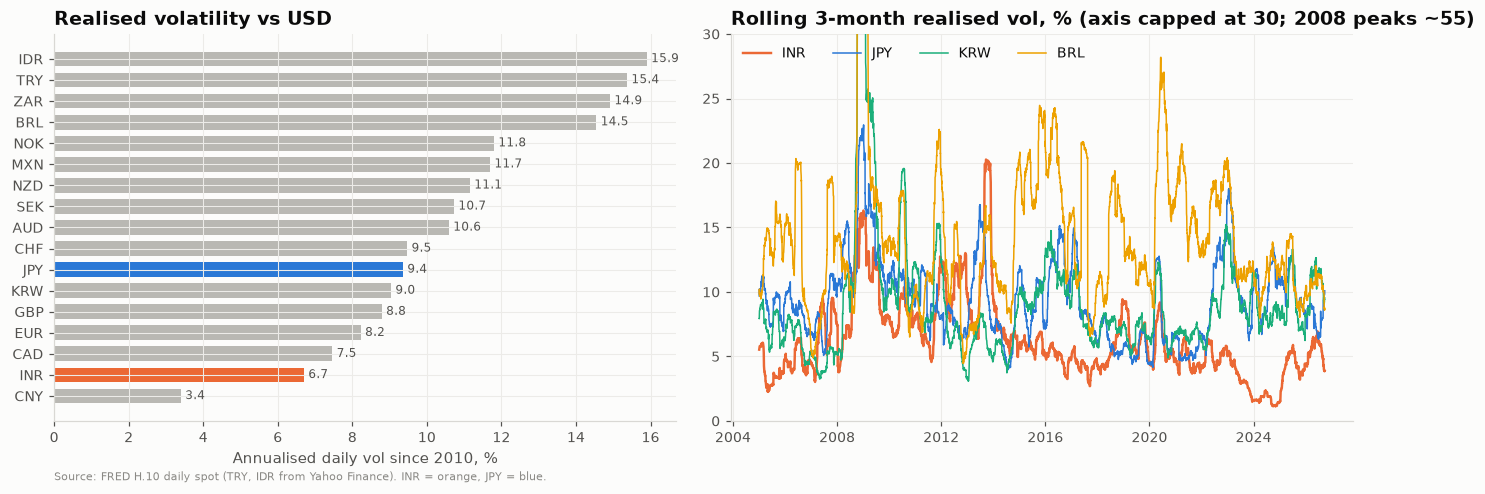

Monthly-return skewness since 2010 (positive = fat tail of foreign-currency DEPRECIATION):
{'SEK': -0.07, 'JPY': 0.02, 'NOK': 0.08, 'AUD': 0.11, 'KRW': 0.15, 'EUR': 0.2, 'NZD': 0.27, 'BRL': 0.27, 'CHF': 0.28, 'INR': 0.3, 'GBP': 0.32, 'CAD': 0.43, 'ZAR': 0.48, 'CNY': 0.54, 'MXN': 1.06, 'IDR': 1.89, 'TRY': 2.58}


In [12]:
daily = {c: fx.spot_daily(c).dropna() for c in spot.columns}
vol = pd.Series({c: 100 * np.log(s["2010":]).diff().std() * np.sqrt(252) for c, s in daily.items()})
skw = pd.Series({c: np.log(s["2010":].resample("ME").last()).diff().skew() for c, s in daily.items()})
vol = vol.sort_values()
fig, (a1, a2) = plt.subplots(1, 2, figsize=(12.5, 4.6))
cols = [fx.CCY_COLOR.get(c, LIGHTGRAY) if c in ("INR", "JPY") else "#b9b8b3" for c in vol.index]
a1.barh(vol.index, vol, color=cols, height=0.7); a1.set_xlabel("Annualised daily vol since 2010, %"); a1.set_title("Realised volatility vs USD")
for i, v in enumerate(vol): a1.annotate(f"{v:.1f}", (v, i), xytext=(3, 0), textcoords="offset points", va="center", fontsize=8, color=INK2)
r1 = pd.DataFrame({c: 100 * np.log(daily[c]).diff().rolling(63).std() * np.sqrt(252) for c in ["INR", "JPY", "KRW", "BRL"]})["2005":]
for c, col in zip(r1, [ORANGE, BLUE, AQUA, YELLOW]):
    a2.plot(r1.index, r1[c], color=col, lw=1.0 if c != "INR" else 1.6, label=c)
a2.set_title("Rolling 3-month realised vol, % (axis capped at 30; 2008 peaks ~55)"); a2.set_ylim(0, 30); a2.legend(loc="upper left", ncol=4)
fx.source_note(a1, "Source: FRED H.10 daily spot (TRY, IDR from Yahoo Finance). INR = orange, JPY = blue.")
fig.tight_layout(); fx.save(fig, "04c_inr_volatility"); plt.show()
print("Monthly-return skewness since 2010 (positive = fat tail of foreign-currency DEPRECIATION):"); print(skw.round(2).sort_values().to_dict())

#### 🔎 What this means

* **T2 supported on volatility.** Since 2010 the rupee's realised vol is **6.7%**, second-lowest in the panel after the CNY (3.4%). That's about half of free-floating EM peers (BRL 14.5%, ZAR 14.9%, IDR 15.9%) and below even the yen (9.4%). The rolling chart shows the RBI keeps INR vol pinned below ~5% except during stress.
* **Vol compression before the break:** in 2023–24 the RBI held rupee vol around **2% (median; range 1–5%)**, effectively a soft peg. The 2025–26 slide began as that grip loosened. For a managed currency, *unusually* low vol is a sign of heavy intervention (and reserves being used), not of safety.
* Low vol makes INR carry *look* safe: a 2–4% rate gap on a 5% vol asset is an attractive ratio. The risk is in the jumps (monthly skew +0.3, i.e. a fat tail of rupee *depreciation*). This is the textbook profile of "picking up nickels in front of a steamroller".

### 4.3 RBI reserves: leaning against the wind (T1b)

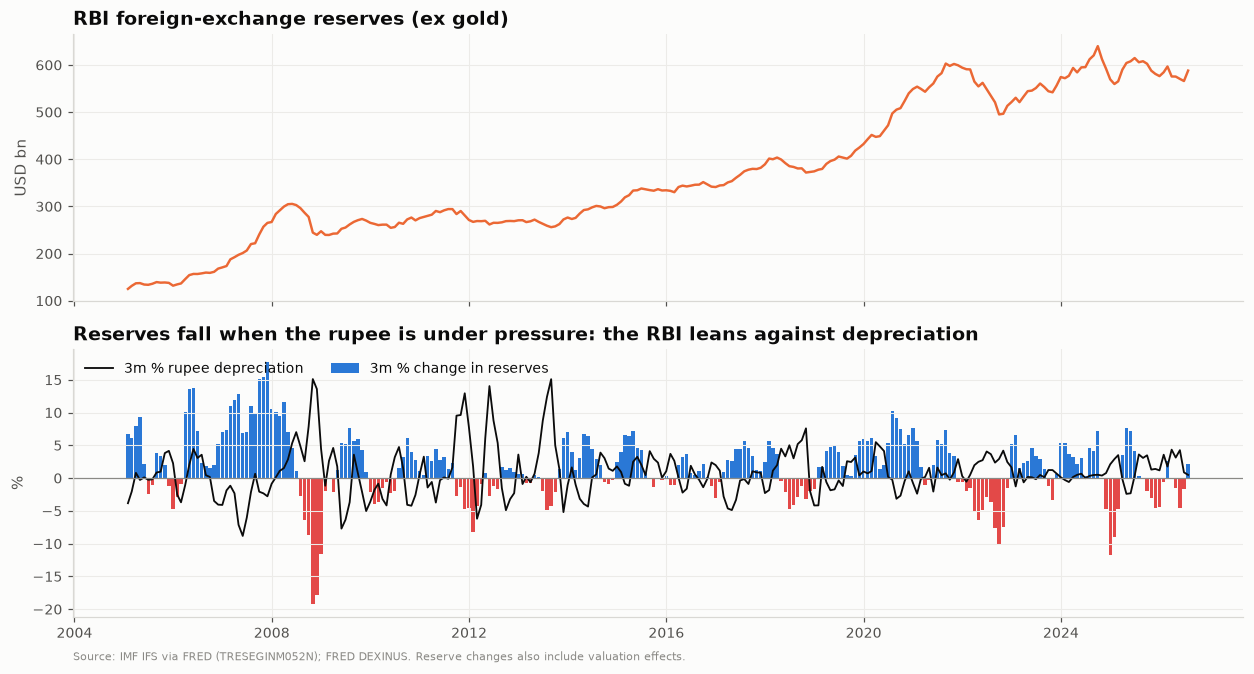

Corr(3m reserve change, 3m depreciation) = -0.50


In [13]:
resv = fx.monthly_last(fx.fred("TRESEGINM052N")) / 1e3
fig, (a1, a2) = plt.subplots(2, 1, figsize=(11.5, 6.2), sharex=True)
a1.plot(resv["2005":].index, resv["2005":], color=ORANGE); a1.set_ylabel("USD bn"); a1.set_title("RBI foreign-exchange reserves (ex gold)")
d3r = 100 * np.log(resv).diff(3); d3s = 100 * np.log(spot["INR"]).diff(3)
dd = pd.DataFrame({"res": d3r, "dep": d3s}).dropna()["2005":]
a2.bar(dd.index, dd.res, width=25, color=[BLUE if v >= 0 else RED for v in dd.res], label="3m % change in reserves")
a2.plot(dd.index, dd.dep, color=INK, lw=1.2, label="3m % rupee depreciation")
a2.axhline(0, color=GRAY, lw=0.8); a2.legend(loc="upper left", ncol=2); a2.set_ylabel("%")
a2.set_title("Reserves fall when the rupee is under pressure: the RBI leans against depreciation")
fx.source_note(a2, "Source: IMF IFS via FRED (TRESEGINM052N); FRED DEXINUS. Reserve changes also include valuation effects.")
fig.tight_layout(); fx.save(fig, "04d_rbi_reserves"); plt.show()
print(f"Corr(3m reserve change, 3m depreciation) = {dd.res.corr(dd.dep):.2f}")

#### 🔎 What this means

* **T1b supported for India.** 3-month reserve changes and 3-month depreciation are strongly negatively correlated (**−0.50**). When the rupee is under pressure the RBI sells dollars, as in 2008, 2013, 2018, 2022 and 2024–26. It rebuilds reserves in calm, inflow-heavy periods.
* This also makes reserves a **real-time stress gauge**. Falling reserves mean the RBI is actively defending and pressure is building. §6.3 turns this into a filter for the long-INR trade.

### 4.4 FCNR(B) swap windows: 2013 vs 2026 (T8)
Both times, the RBI offered banks a **subsidised USD/INR swap** for new foreign-currency deposits from non-resident Indians, absorbing the hedging cost so banks could pay NRIs high dollar rates. 2013: announced 4 Sept 2013 (Rajan's first day), window to 30 Nov 2013, raised ~$34bn. 2026: deposits from 8 June 2026, window **closed early** on 31 Aug 2026 after raising **$52.3bn**.

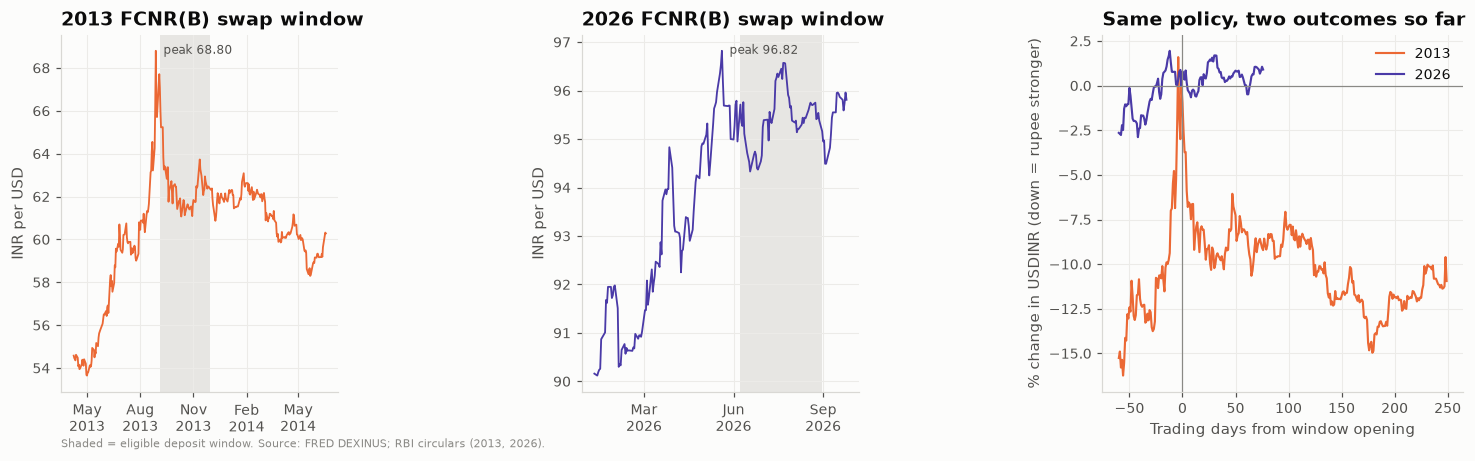

,USDINR before,90d pre-window peak,% during window,% +3m after open,% +6m,% +12m,latest
window,,,,,,,
2013 FCNR(B) swap window,67.71,68.80,-8.33,-9.46,-10.70,-11.66,95.81
2026 FCNR(B) swap window,94.95,96.82,0.22,-0.14,NaN,NaN,95.81


In [14]:
windows = {"2013 FCNR(B) swap window": ("2013-09-04", "2013-11-30", ORANGE),
           "2026 FCNR(B) swap window": ("2026-06-08", "2026-08-31", VIOLET)}
fig, axes = plt.subplots(1, 3, figsize=(13.5, 4.3), gridspec_kw={"width_ratios": [1, 1, 1.3]})
for ax, (lbl, (a, b, col)) in zip(axes[:2], windows.items()):
    seg = ind[pd.Timestamp(a) - pd.Timedelta(days=150): pd.Timestamp(b) + pd.Timedelta(days=200)]
    ax.plot(seg.index, seg, color=col, lw=1.2); ax.axvspan(pd.Timestamp(a), pd.Timestamp(b), color=LIGHTGRAY, alpha=0.6, lw=0)
    ax.set_title(lbl); ax.set_ylabel("INR per USD"); ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3)); ax.xaxis.set_major_formatter(mdates.DateFormatter("%b\n%Y"))
    pk = seg[:b].idxmax(); ax.annotate(f"peak {seg[pk]:.2f}", (pk, seg[pk]), xytext=(5, -2), textcoords="offset points", fontsize=8, color=INK2)
ax = axes[2]
for lbl, (a, b, col) in windows.items():
    i = ind.index.searchsorted(pd.Timestamp(a)); base = ind.iloc[i - 1]
    seg = ind.iloc[i - 60:i + 250]
    ax.plot(np.arange(len(seg)) - 60, 100 * np.log(seg.values / base), color=col, lw=1.4, label=lbl[:4])
ax.axvline(0, color=GRAY, lw=0.8); ax.axhline(0, color=GRAY, lw=0.8)
ax.set_xlabel("Trading days from window opening"); ax.set_ylabel("% change in USDINR (down = rupee stronger)")
ax.set_title("Same policy, two outcomes so far"); ax.legend(loc="upper right")
fx.source_note(axes[0], "Shaded = eligible deposit window. Source: FRED DEXINUS; RBI circulars (2013, 2026).")
fig.tight_layout(); fx.save(fig, "04e_fcnr_2013_vs_2026"); plt.show()

rows = []
for lbl, (a, b, _) in windows.items():
    ia, ib = ind.index.searchsorted(pd.Timestamp(a)), ind.index.searchsorted(pd.Timestamp(b))
    pre_peak = ind[:a].iloc[-90:].max()
    f = lambda k: 100 * np.log(ind.iloc[k] / ind.iloc[ia - 1]) if k < len(ind) else np.nan
    rows.append({"window": lbl, "USDINR before": ind.iloc[ia - 1], "90d pre-window peak": pre_peak,
                 "% during window": f(ib), "% +3m after open": f(ia + 63), "% +6m": f(ia + 126), "% +12m": f(ia + 252),
                 "latest": ind.iloc[-1]})
pd.DataFrame(rows).set_index("window")

#### 🔎 What this means

* **2013:** the window opened a week after the rupee's all-time low at the time (68.8). The rupee rallied **8.3% during the window** and was **~12% stronger a year later**. It is widely cited as the policy that ended the taper tantrum. But the timing was lucky too: on **18 Sept 2013 the Fed surprised by *not* tapering**, a major global tailwind.
* **2026:** the window raised **more** money ($52.3bn, closed early on 31 Aug) and the rupee is **flat** (95.0 → 95.8). The global backdrop is the opposite of 2013: the Fed *hiked* on 16 Sept 2026, oil is ~$100, and portfolio outflows continue.
* **T8 verdict: not supported so far.** The same tool worked in 2013 alongside a global tailwind and hasn't worked in 2026 without one. This fits the Japan evidence: **domestic defence buys time; global rates decide the trend.**
* One more angle: the FCNR deposits are **3–5-year** dollar liabilities that the RBI has swapped. When they mature (2029–31) the RBI must deliver dollars back, a known future outflow the market may start to price.

### 4.5 Carry P&L decomposition: where do the returns actually come from?
Split each trade into **interest earned** vs. **spot FX gain/loss**. UIP says these should cancel out.

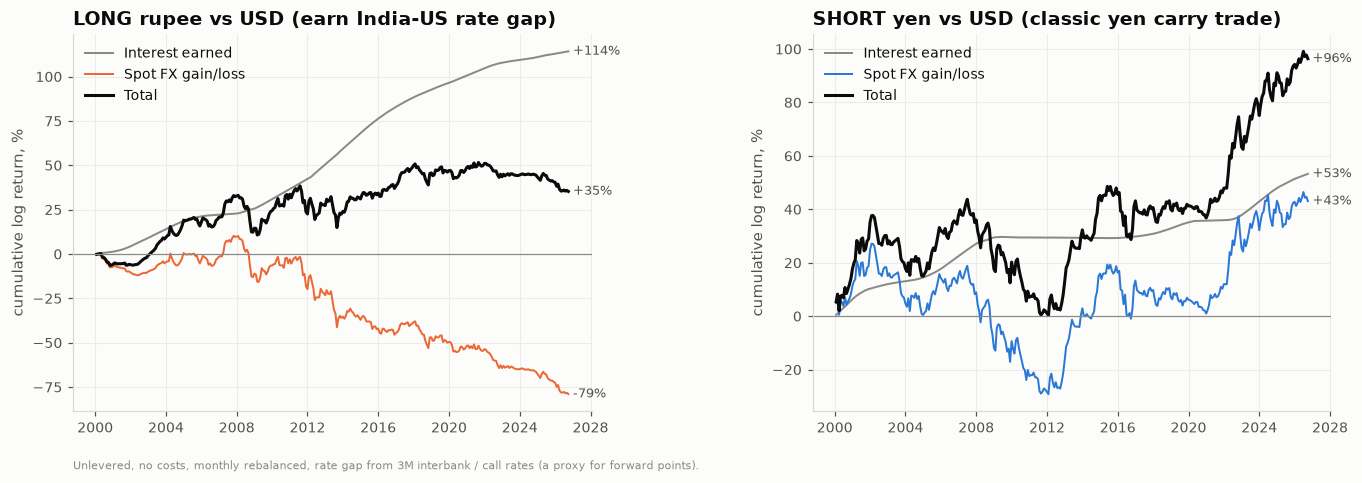

,Ann. return %,Ann. vol %,Sharpe,Skew,Worst month %,Max drawdown %,Hit rate %,Months
Long INR carry,1.29,6.48,0.20,-0.26,-7.06,-20.92,57.53,332.00
Short JPY carry,3.20,9.49,0.34,0.11,-7.44,-35.24,52.11,332.00
"Long INR, 2013-26",0.58,5.84,0.10,-0.08,-7.06,-15.99,52.73,165.00
"Short JPY, 2013-26",6.07,9.14,0.66,-0.06,-7.44,-18.04,53.94,165.00


In [15]:
fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.5))
for ax, code_, sign, title in [(axes[0], "INR", 1, "LONG rupee vs USD (earn India-US rate gap)"),
                                (axes[1], "JPY", -1, "SHORT yen vs USD (classic yen carry trade)")]:
    df = pd.DataFrame({"Interest earned": sign * carry[code_].shift(1) / 12, "Spot FX move": sign * -ds[code_]}).dropna()["2000":]
    cum = 100 * df.cumsum(); tot = cum.sum(axis=1)
    ax.plot(cum.index, cum["Interest earned"], color=GRAY, lw=1.3, label="Interest earned")
    ax.plot(cum.index, cum["Spot FX move"], color=fx.CCY_COLOR[code_], lw=1.3, label="Spot FX gain/loss")
    ax.plot(tot.index, tot, color=INK, lw=2.0, label="Total")
    for s, c in [(cum["Interest earned"], GRAY), (cum["Spot FX move"], fx.CCY_COLOR[code_]), (tot, INK)]:
        ax.annotate(f"{s.iloc[-1]:+.0f}%", (s.index[-1], s.iloc[-1]), xytext=(3, 0), textcoords="offset points", fontsize=8.5, color=INK2, va="center")
    ax.axhline(0, color=GRAY, lw=0.8); ax.set_title(title); ax.set_ylabel("cumulative log return, %"); ax.legend(loc="upper left")
fx.source_note(axes[0], "Unlevered, no costs, monthly rebalanced, rate gap from 3M interbank / call rates (a proxy for forward points).")
fig.tight_layout(); fx.save(fig, "04f_carry_decomposition_inr_jpy"); plt.show()
fx.perf_table({"Long INR carry": rx["INR"], "Short JPY carry": -rx["JPY"],
               "Long INR, 2013-26": rx["INR"]["2013":], "Short JPY, 2013-26": -rx["JPY"]["2013":]}).round(2)

#### 🔎 What this means

* **Long INR** (2000–26): the rupee paid **+114% (log) in interest** but lost **−79% on the exchange rate**, for a total of **+35%**. That's 1.3%/yr at 6.5% vol (Sharpe 0.20), and **almost nothing since 2018**.
* **Short JPY** (2000–26): **+53% interest *plus* +43% from the yen weakening**, for **+96%** (Sharpe 0.34 overall, **0.66 since 2013**). Here both parts of the trade paid, which is exactly what UIP says shouldn't happen.
* So the *funding* side (short yen) has been the better half of the carry trade for a decade. Since 2013, the rupee's high yield has been almost completely offset by its depreciation.

---
## 5. Cross-country panel: does the pattern generalise?
Japan and India are two data points. To test the idea properly we need many currencies over many years. **Universe:** 9 G10 currencies (JPY, EUR, GBP, CHF, CAD, AUD, NZD, NOK, SEK) + 8 EM (INR, CNY, KRW, BRL, MXN, ZAR, TRY, IDR), monthly, 1999–2026.

| # | Theory | Supported if… | Refuted if… |
|---|---|---|---|
| T0 | UIP fails (baseline, well known) | Fama β < 1 | β ≈ 1 |
| T1 | **Team thesis:** net-importer high-yielders are "defended", so they deviate from UIP (depreciate *less*) and carry pays *more* on them | Net-importer β lower than net-exporter β; high-carry net importers earn more carry return | The opposite: net importers track UIP more closely / earn less |
| T1b | Net importers spend reserves to fight depreciation more than exporters | Defence intensity higher for deficit countries | No relationship |
| T2 | Carry = crash risk | Higher carry ↔ more negative skew; carry loses when VIX spikes | No relationship |
| T4 | **UIP "tension"** — a big cumulative gap between actual and UIP path predicts reversal | Currencies far *above* their UIP path subsequently underperform | No predictive power |
| T5 | Crowding predicts reversals | Contrarian positioning portfolio earns positive returns | Zero / negative |
| T7 | Valuation mean-reverts | Cheap-REER currencies outperform | Zero / negative |

### 5.1 The universe at a glance (2000–2026 averages)

In [16]:
since = "2000"
char = pd.DataFrame({
    "Group": {c.code: c.group for c in fx.UNIVERSE},
    "Avg carry vs USD %": 100 * carry[since:].mean(),
    "Avg trade bal % of trade": tb[since:].mean(),
    "% months net exporter": 100 * (tb[since:] > 0).sum() / tb[since:].notna().sum(),
    "Avg current acct % GDP": ca[since:].mean(),
    "Carry-trade ann. return %": 1200 * rx[since:].mean(),
    "Ann. vol %": 100 * rx[since:].std() * np.sqrt(12),
    "Skew": rx[since:].skew(),
}).sort_values("Avg carry vs USD %")
char

,Group,Avg carry vs USD %,Avg trade bal % of trade,% months net exporter,Avg current acct % GDP,Carry-trade ann. return %,Ann. vol %,Skew
JPY,G10,-1.98,1.77,54.83,2.98,-3.60,9.51,-0.12
CHF,G10,-1.81,6.39,95.02,8.01,0.63,9.66,0.18
SEK,G10,-0.66,3.68,83.49,5.21,-1.23,10.95,-0.02
EUR,G10,-0.59,2.11,66.19,NaN,-0.13,9.18,-0.13
CAD,G10,-0.15,2.13,59.19,-0.84,-0.07,8.36,-0.60
GBP,G10,0.45,-16.34,0.00,-2.94,-0.29,8.56,-0.32
NOK,G10,0.87,23.82,100.00,11.62,0.23,11.57,-0.24
CNY,EM,0.90,9.26,100.00,3.03,1.69,3.38,-0.65
KRW,EM,0.97,4.08,91.15,3.13,0.32,10.54,-0.10
AUD,G10,1.52,2.55,61.06,-3.40,1.77,11.85,-0.57


### 5.2 UIP ('Fama') regressions (T0, T1)
Regress next month's depreciation on today's rate gap. **β = 1** means UIP holds; **β = 0** means the rate gap tells you nothing about future FX moves (so the carry is "free"); **β < 0** means high-rate currencies actually appreciate.

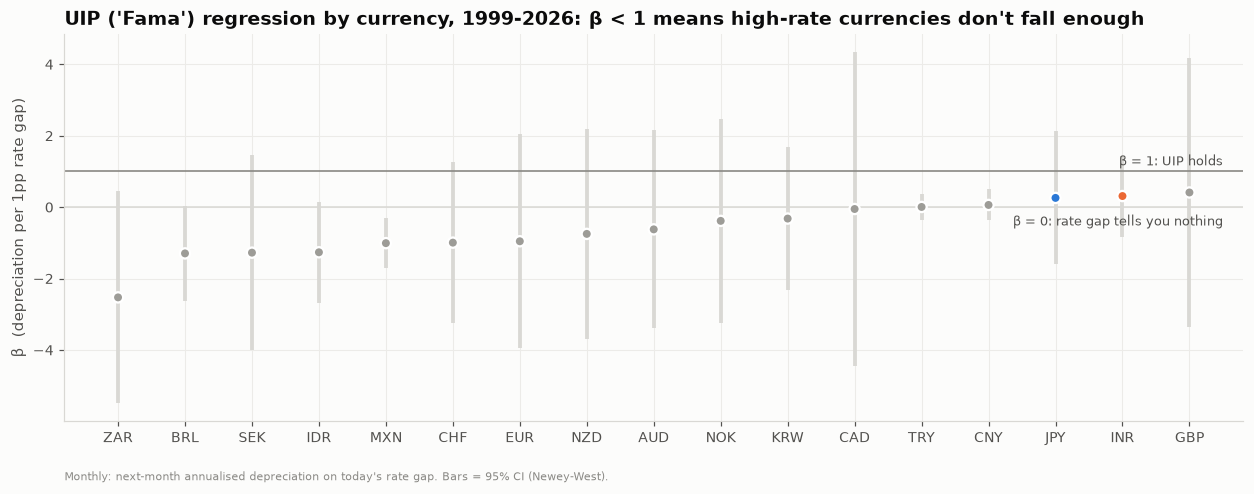

,beta,se,t-stat vs UIP (β=1),obs
All currency-months,0.25,0.15,-5.09,"5,152.00"
Net exporters (trade > 0),-0.20,0.26,-4.66,"2,937.00"
Net importers (trade <= 0),0.41,0.19,-3.11,"2,215.00"
Current-account surplus,-0.53,0.29,-5.20,"2,469.00"
Current-account deficit,0.34,0.18,-3.62,"2,683.00"


Interaction model: dep = a + b·gap + c·(gap × net-importer) + d·net-importer
                 coef     t
const            0.00  0.39
carry           -0.20 -0.78
carry_x_deficit  0.61  2.03
deficit          0.02  1.79


In [17]:
rows = {}
for c in spot:
    m = fx.nw_ols(ds[c].shift(-1) * 12, carry[c].rename("carry"))
    rows[c] = {"beta": m.params["carry"], "se": m.bse["carry"], "n": int(m.nobs)}
fama = pd.DataFrame(rows).T.sort_values("beta")
L = pd.DataFrame({"dsf": (ds.shift(-1) * 12).stack(), "carry": carry.stack(), "tb": tb.stack(), "ca": ca.stack()}).dropna()
pooled = {"All currency-months": fx.nw_ols(L.dsf, L[["carry"]])}
for nm, sub in [("Net exporters (trade > 0)", L[L.tb > 0]), ("Net importers (trade <= 0)", L[L.tb <= 0]),
                ("Current-account surplus", L[L.ca > 0]), ("Current-account deficit", L[L.ca <= 0])]:
    pooled[nm] = fx.nw_ols(sub.dsf, sub[["carry"]])
L["carry_x_deficit"] = L.carry * (L.tb <= 0); L["deficit"] = (L.tb <= 0).astype(float)
inter = fx.nw_ols(L.dsf, L[["carry", "carry_x_deficit", "deficit"]])

fig, ax = plt.subplots(figsize=(11.5, 4.6))
x = np.arange(len(fama))
cols = [fx.CCY_COLOR.get(c, "#9d9c97") if c in ("JPY", "INR") else "#9d9c97" for c in fama.index]
ax.errorbar(x, fama.beta, yerr=1.96 * fama.se, fmt="none", ecolor=LIGHTGRAY, elinewidth=2.5, capsize=0)
ax.scatter(x, fama.beta, color=cols, s=45, zorder=3, edgecolor="white", linewidth=1.5)
ax.axhline(1, color=GRAY, lw=1.1); ax.annotate("β = 1: UIP holds", (len(fama) - 0.5, 1), xytext=(0, 4), textcoords="offset points", ha="right", fontsize=8.5, color=INK2)
ax.axhline(0, color=LIGHTGRAY, lw=1.0); ax.annotate("β = 0: rate gap tells you nothing", (len(fama) - 0.5, 0), xytext=(0, -12), textcoords="offset points", ha="right", fontsize=8.5, color=INK2)
ax.set_xticks(x); ax.set_xticklabels(fama.index); ax.set_ylabel("β  (depreciation per 1pp rate gap)")
ax.set_title("UIP ('Fama') regression by currency, 1999-2026: β < 1 means high-rate currencies don't fall enough")
fx.source_note(ax, "Monthly: next-month annualised depreciation on today's rate gap. Bars = 95% CI (Newey-West).")
fig.tight_layout(); fx.save(fig, "05a_fama_betas"); plt.show()
out = pd.DataFrame({k: {"beta": m.params["carry"], "se": m.bse["carry"], "t-stat vs UIP (β=1)": (m.params["carry"] - 1) / m.bse["carry"], "obs": int(m.nobs)} for k, m in pooled.items()}).T
display(out)
print("Interaction model: dep = a + b·gap + c·(gap × net-importer) + d·net-importer")
print(pd.DataFrame({"coef": inter.params, "t": inter.tvalues}).round(2))

#### 🔎 What this means

* **T0 confirmed:** every currency's β is below 1, and the pooled β is **0.25** (t = −5.1 against UIP). Many are negative (high-rate currencies *appreciated* on average). The point estimates are noisy per currency; the pooled result is the reliable one.
* **T1 (team thesis) — the opposite of what we hypothesised.** Net importers have a **higher** β (**0.41**) than net exporters (**−0.20**). The interaction term is +0.61 (t = 2.0), and the current-account split shows the same pattern. **Deficit currencies follow UIP *more* closely**: when they offer high rates, they tend to depreciate by more of the rate gap. Surplus currencies with high rates tend to hold up or appreciate.
* Economic intuition: a deficit country *needs* capital inflows, and part of its high rate is **compensation for depreciation/crash risk**, which then shows up. A surplus country with high rates (BRL and IDR in commodity booms, NOK) is paying a rate that isn't needed to fund an external gap, so the carry is closer to "free".

### 5.3 Carry vs. return vs. crash risk (T2)

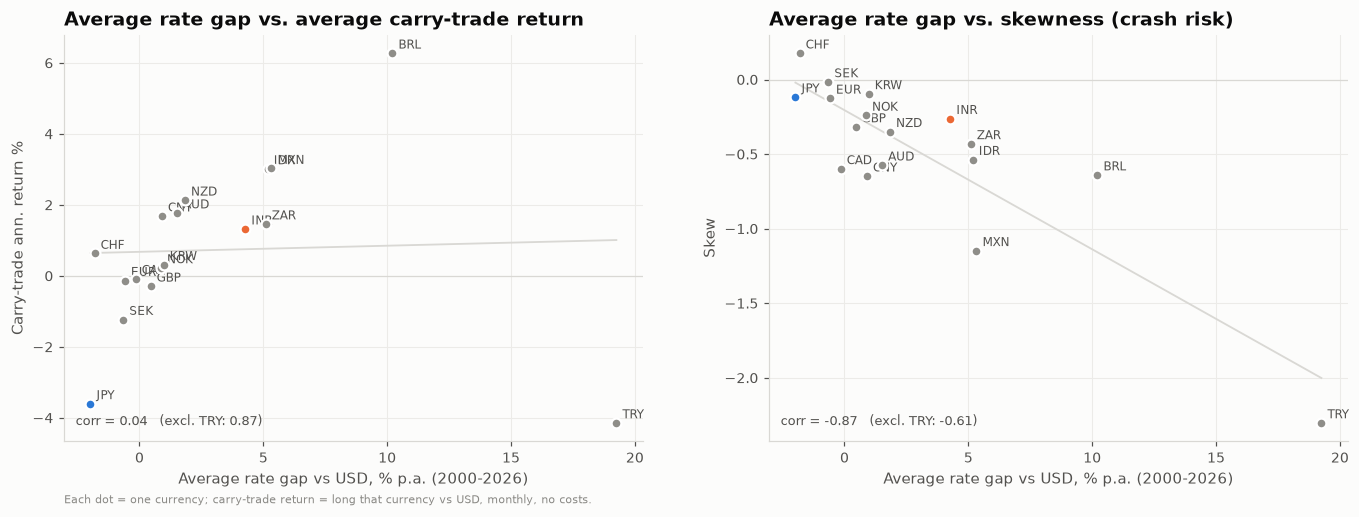

In [18]:
fig, (a1, a2) = plt.subplots(1, 2, figsize=(12.5, 4.8))
X = char["Avg carry vs USD %"]
for ax, ycol, ttl in [(a1, "Carry-trade ann. return %", "Average rate gap vs. average carry-trade return"),
                      (a2, "Skew", "Average rate gap vs. skewness (crash risk)")]:
    Y = char[ycol]
    for c in char.index:
        col = fx.CCY_COLOR.get(c, "#8f8e89") if c in ("JPY", "INR") else "#8f8e89"
        ax.scatter(X[c], Y[c], color=col, s=42, edgecolor="white", linewidth=1.5, zorder=3)
        ax.annotate(c, (X[c], Y[c]), xytext=(4, 3), textcoords="offset points", fontsize=8, color=INK2)
    b = np.polyfit(X, Y, 1); xx = np.linspace(X.min(), X.max(), 10)
    ax.plot(xx, np.polyval(b, xx), color=LIGHTGRAY, lw=1.2); ax.axhline(0, color=LIGHTGRAY, lw=0.8)
    ax.set_xlabel("Average rate gap vs USD, % p.a. (2000-2026)"); ax.set_ylabel(ycol); ax.set_title(ttl)
    ax.annotate(f"corr = {X.corr(Y):.2f}   (excl. TRY: {X.drop('TRY').corr(Y.drop('TRY')):.2f})", xy=(0.02, 0.04), xycoords="axes fraction", fontsize=8.5, color=INK2)
fx.source_note(a1, "Each dot = one currency; carry-trade return = long that currency vs USD, monthly, no costs.")
fig.tight_layout(); fx.save(fig, "05b_carry_vs_return_and_skew"); plt.show()

#### 🔎 What this means

* **T2 confirmed across currencies:** a higher average rate gap goes with more negative skew (corr **−0.87** across all 17, −0.61 excluding TRY). High-yielders earn their premium by occasionally crashing.
* Average carry vs. average return is **~0 with TRY** (Turkey's 19% average rate gap came with a −4%/yr return) but **0.87 excluding TRY**. One hyperinflationary outlier can erase the whole premium. That's an argument for **diversified** carry and against concentrated single-currency carry.

### 5.4 ⭐ The core test: carry × trade balance (T1)
Each month, split currencies into **high carry / low carry** (above/below the median rate gap that month) and **net exporter / net importer** (sign of the 12-month trade balance, lagged 2 months). Then compare next-month carry-trade returns across the four buckets.

The team's thesis is about the **High carry × Net importer** bucket (currencies that UIP says should fall *and* that trade flows push down, but that central banks defend).

A) Raw carry-trade returns (long foreign ccy vs USD) by carry and trade-balance bucket


Ann. return %  Ann. vol %  Skew  Worst month %  Currency-months
High carry Net exporter           4.36       12.73 -0.51         -22.26             1167
           Net importer           1.07       12.79 -1.34         -30.97             1434
Low carry  Net exporter          -0.26        9.51 -0.13         -13.86             1968
           Net importer          -1.76       10.10 -0.04         -13.76              903

B) Same, dollar-neutral (removes the broad-USD trend that hits every currency at once)


Ann. return %  Ann. vol %  Skew  Worst month %  Currency-months
High carry Net exporter           3.04        9.92 -0.44         -20.89             1167
           Net importer           0.57       10.20 -1.40         -26.59             1434
Low carry  Net exporter          -1.38        6.91  0.63          -7.01             1968
           Net importer          -1.80        7.21 -0.12         -11.26              903

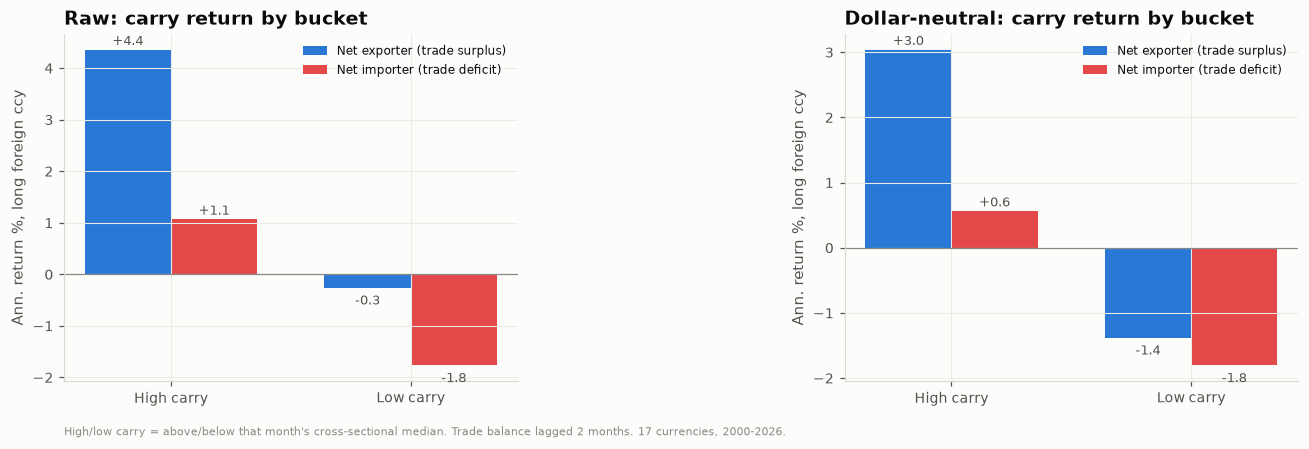

C) Robustness: return spread between net exporters and net importers within each carry bucket (dollar-neutral, % p.a.)


High carry: exporter minus importer (pp)  Low carry: exporter minus importer (pp)
Baseline        trade balance                                        2.48                                     0.42
                current account                                      2.34                                    -1.13
2000-2012       trade balance                                        2.20                                     0.74
                current account                                      3.00                                    -0.85
2013-2026       trade balance                                        2.89                                     0.42
                current account                                      1.18                                    -1.18
Excl. TRY       trade balance                                        1.51                                     0.59
                current account                                      2.15                                    -1.32
Excl. TRY & BRL trade balance                                        0.77                                     0.48
                current account                                      1.84                                    -1.56
G10 only        trade balance                                        0.66                                    -0.21
                current account                                     -0.44                                    -3.49
EM only         trade balance                                        2.90                                     2.37
                current account                                      2.80                                     3.79

In [19]:
def two_by_two(r, key_df, excl=(), start=None, end=None, only=None):
    L2 = pd.DataFrame({"r": r.shift(-1).stack(), "carry": carry.stack(), "k": key_df.stack()}).dropna()
    cc = L2.index.get_level_values(1); dd = L2.index.get_level_values(0)
    keep = ~cc.isin(excl)
    if only is not None: keep &= cc.isin(only)
    if start: keep &= dd >= pd.Timestamp(start)
    if end: keep &= dd <= pd.Timestamp(end)
    L2 = L2[keep]
    hi = L2.groupby(level=0).carry.transform(lambda x: x > x.median())
    g = L2.groupby([np.where(hi, "High carry", "Low carry"), np.where(L2.k > 0, "Net exporter", "Net importer")]).r
    return pd.DataFrame({"Ann. return %": 1200 * g.mean(), "Ann. vol %": 100 * np.sqrt(12) * g.std(), "Skew": g.skew(),
                         "Worst month %": 100 * g.min(), "Currency-months": g.size()})

rx_dn = rx.sub(rx.mean(axis=1), axis=0)          # dollar-neutral: subtract the average currency each month
base = two_by_two(rx, tb); neutral = two_by_two(rx_dn, tb)
print("A) Raw carry-trade returns (long foreign ccy vs USD) by carry and trade-balance bucket"); display(base)
print("B) Same, dollar-neutral (removes the broad-USD trend that hits every currency at once)"); display(neutral)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.2), sharey=False)
for ax, tbl, ttl in [(axes[0], base, "Raw"), (axes[1], neutral, "Dollar-neutral")]:
    t = tbl["Ann. return %"].unstack()
    xx = np.arange(2); w = 0.36
    ax.bar(xx - w / 2, t["Net exporter"], width=w, color=BLUE, label="Net exporter (trade surplus)")
    ax.bar(xx + w / 2, t["Net importer"], width=w, color=RED, label="Net importer (trade deficit)")
    for i, c in enumerate(t.index):
        for off, col in [(-w / 2, "Net exporter"), (w / 2, "Net importer")]:
            v = t.loc[c, col]; ax.annotate(f"{v:+.1f}", (i + off, v), xytext=(0, 3 if v >= 0 else -11), textcoords="offset points", ha="center", fontsize=8.5, color=INK2)
    ax.set_xticks(xx); ax.set_xticklabels(t.index); ax.axhline(0, color=GRAY, lw=0.8)
    ax.set_ylabel("Ann. return %, long foreign ccy"); ax.set_title(f"{ttl}: carry return by bucket"); ax.legend(loc="upper right", fontsize=8)
fx.source_note(axes[0], "High/low carry = above/below that month's cross-sectional median. Trade balance lagged 2 months. 17 currencies, 2000-2026.")
fig.tight_layout(); fx.save(fig, "05c_two_by_two_carry_trade_balance"); plt.show()

em = [c for c in spot if fx.U[c].group == "EM"]; g10 = [c for c in spot if fx.U[c].group == "G10"]
variants = {"Baseline": {}, "2000-2012": {"end": "2012-12-31"}, "2013-2026": {"start": "2013-01-01"},
            "Excl. TRY": {"excl": ("TRY",)}, "Excl. TRY & BRL": {"excl": ("TRY", "BRL")}, "G10 only": {"only": g10}, "EM only": {"only": em}}
rob = {}
for nm, kw in variants.items():
    for lab, key in [("trade balance", tb), ("current account", ca)]:
        t = two_by_two(rx_dn, key, **kw)["Ann. return %"]
        rob[(nm, lab)] = {"High carry: exporter minus importer (pp)": t.get(("High carry", "Net exporter"), np.nan) - t.get(("High carry", "Net importer"), np.nan),
                          "Low carry: exporter minus importer (pp)": t.get(("Low carry", "Net exporter"), np.nan) - t.get(("Low carry", "Net importer"), np.nan)}
print("C) Robustness: return spread between net exporters and net importers within each carry bucket (dollar-neutral, % p.a.)")
pd.DataFrame(rob).T

#### 🔎 What this means

**This is the most important table for the thesis.**
* **The team's bucket (High carry × Net importer) is the *worst* way to harvest carry.** Dollar-neutral it earned **+0.6%/yr** vs **+3.0%/yr** for high-carry net exporters, with **skew −1.40 vs −0.44** and a worst month of **−27% vs −21%**.
* **Robust:** the exporter-minus-importer spread among high-carry currencies is positive in **both halves** (+2.2pp 2000–12, +2.9pp 2013–26), **excluding TRY** (+1.5pp) and **TRY & BRL** (+0.8pp), in **G10 only** (+0.7pp) and **EM only** (+2.9pp), and with the **current account** instead of trade (+2.3pp; G10-only CA is the one exception at −0.4pp). The effect is largest in EM.
* **Reframing the thesis:** central banks of net importers *do* defend (§4.3, §5.5), but the defence doesn't create a free lunch. It **delays** depreciation and then **concentrates** it into crashes. The profitable deviation from UIP is in the **net exporters**, whose high rates aren't needed to attract capital.
* So the pitch shifts from *"bet on defended net importers"* to ***"harvest carry where the trade balance supports it, avoid it where the trade balance undermines it"***, which is §6's strategy.

### 5.5 Who defends their currency? (T1b)
Monthly change in FX reserves regressed separately on **depreciation** and **appreciation** months, controlling for moves in the broad dollar (reserves held in EUR/JPY lose USD value when the dollar rises, which would otherwise look like "intervention").

,Defence: reserve % lost per 1% depreciation,t (defence),Accumulation: reserve % gained per 1% appreciation,t (accum.),Avg trade bal %,Avg CA % GDP
AUD,0.63,1.66,0.03,0.06,4.71,-3.04
CNY,0.46,3.10,-0.26,-1.89,10.60,3.27
JPY,0.22,3.61,0.12,2.25,-0.72,3.07
INR,0.21,2.86,-0.11,-0.96,-20.66,-1.63
TRY,0.20,1.22,-0.02,-0.09,-17.94,-3.58
IDR,0.15,1.26,0.10,1.30,6.50,-0.55
KRW,0.12,2.06,-0.08,-1.18,3.89,3.38
BRL,0.04,0.49,-0.16,-2.42,9.60,-2.16
MXN,0.03,0.32,-0.33,-2.16,-0.80,-1.01
ZAR,0.02,0.44,0.01,0.20,0.90,-2.38


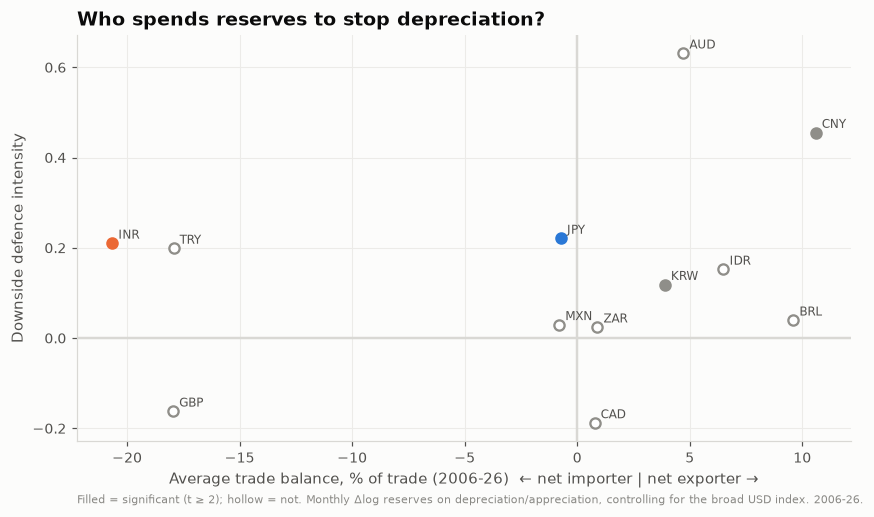

Correlation(defence intensity, avg trade balance) = 0.26 (n=12)


In [20]:
usd = np.log(fx.monthly_last(fx.fred("DTWEXBGS"))).diff()
rows = {}
for c in [k for k in spot if fx.U[k].reserves]:
    r = np.log(fx.monthly_last(fx.fred(f"TRESEG{fx.U[c].reserves}M052N"))).diff()
    d = pd.DataFrame({"dres": r, "dep": ds[c].clip(lower=0), "app": ds[c].clip(upper=0), "usd": usd}).dropna()["2006":]
    m = fx.nw_ols(d.dres, d[["dep", "app", "usd"]])
    rows[c] = {"Defence: reserve % lost per 1% depreciation": -m.params["dep"], "t (defence)": -m.tvalues["dep"],
               # appreciation enters as a negative ds, so reserve build-up shows as a negative coefficient
               "Accumulation: reserve % gained per 1% appreciation": -m.params["app"], "t (accum.)": -m.tvalues["app"],
               "Avg trade bal %": tb[c]["2006":].mean(), "Avg CA % GDP": ca[c]["2006":].mean()}
lw = pd.DataFrame(rows).T
lw = lw.sort_values("Defence: reserve % lost per 1% depreciation", ascending=False)
display(lw)

fig, ax = plt.subplots(figsize=(8.5, 4.8))
for c, r in lw.iterrows():
    col = fx.CCY_COLOR.get(c, "#8f8e89") if c in ("JPY", "INR") else "#8f8e89"
    sig = r["t (defence)"] >= 2   # filled = statistically significant (t >= 2), hollow = not
    ax.scatter(r["Avg trade bal %"], r["Defence: reserve % lost per 1% depreciation"], s=45, color=col if sig else "white", edgecolor=col, linewidth=1.5, zorder=3)
    ax.annotate(c, (r["Avg trade bal %"], r["Defence: reserve % lost per 1% depreciation"]), xytext=(4, 3), textcoords="offset points", fontsize=8, color=INK2)
ax.axvline(0, color=LIGHTGRAY); ax.axhline(0, color=LIGHTGRAY)
ax.set_xlabel("Average trade balance, % of trade (2006-26)  ← net importer | net exporter →")
ax.set_ylabel("Downside defence intensity")
ax.set_title("Who spends reserves to stop depreciation?")
fx.source_note(ax, "Filled = significant (t ≥ 2); hollow = not. Monthly Δlog reserves on depreciation/appreciation, controlling for the broad USD index. 2006-26.")
fig.tight_layout(); fx.save(fig, "05d_defence_vs_trade_balance"); plt.show()
print(f"Correlation(defence intensity, avg trade balance) = {lw.iloc[:,0].corr(lw['Avg trade bal %']):.2f} (n={len(lw)})")

#### 🔎 What this means

* **Statistically significant downside defenders** (filled dots): **CNY, JPY, INR, KRW**. These are managed or intervention-prone regimes. Free floaters (MXN, ZAR, BRL, GBP, CAD) show nothing, as they should.
* **T1b (net importers defend more) is *not* supported in the cross-section.** The correlation between defence intensity and trade balance is +0.26 (if anything, exporters like CNY defend more), and India (deficit) and China (surplus) both defend. **Defence depends on the policy regime more than the trade position.** The trade position (Japan §3.2) shapes *which direction* a country cares about; whether it acts depends on its reserves and institutions.
* Caveats: 12 countries, monthly data, and reserve changes include interest income and non-USD valuation even after the USD control. AUD's high point estimate is not significant.

### 5.6 Signal horse race (T4, T5, T7 vs. carry and trade balance)
Same recipe for every signal: each month go **long the top third** of currencies and **short the bottom third**, hold one month. No costs yet.

Long top-third / short bottom-third of currencies by each signal, rebalanced monthly, no costs:


,Ann. return %,Ann. vol %,Sharpe,Skew,Max drawdown %,Months,Ret 2000-12 %,Ret 2013-26 %,t-stat
Carry (rate gap),4.89,8.00,0.61,-0.79,-17.86,332.00,6.84,2.91,3.21
Trade balance vs own 5y avg (timing only),3.10,5.99,0.52,0.18,-11.18,297.00,3.85,2.49,2.57
Trade balance,1.97,5.56,0.35,0.38,-14.06,332.00,1.17,2.77,1.86
Trade balance 12m change,1.83,5.55,0.33,-0.20,-16.84,320.00,0.66,2.93,1.71
Momentum 12m,0.83,7.23,0.11,-0.11,-33.18,320.00,1.27,0.41,0.59
UIP 'tension' 36m (cum. deviation),-0.28,6.36,-0.04,-0.19,-24.58,296.00,-1.91,1.01,-0.22
Momentum 3m,-0.71,7.00,-0.10,0.30,-39.36,329.00,0.88,-2.30,-0.53
Value: REER vs 5y avg (cheap = long),-0.72,6.52,-0.11,0.46,-28.21,273.00,0.34,-1.41,-0.53
Contrarian positioning (CFTC),-1.10,6.85,-0.16,0.18,-33.61,320.00,-1.26,-0.96,-0.83
Current account,-1.97,7.30,-0.27,0.52,-41.91,332.00,-3.32,-0.62,-1.42


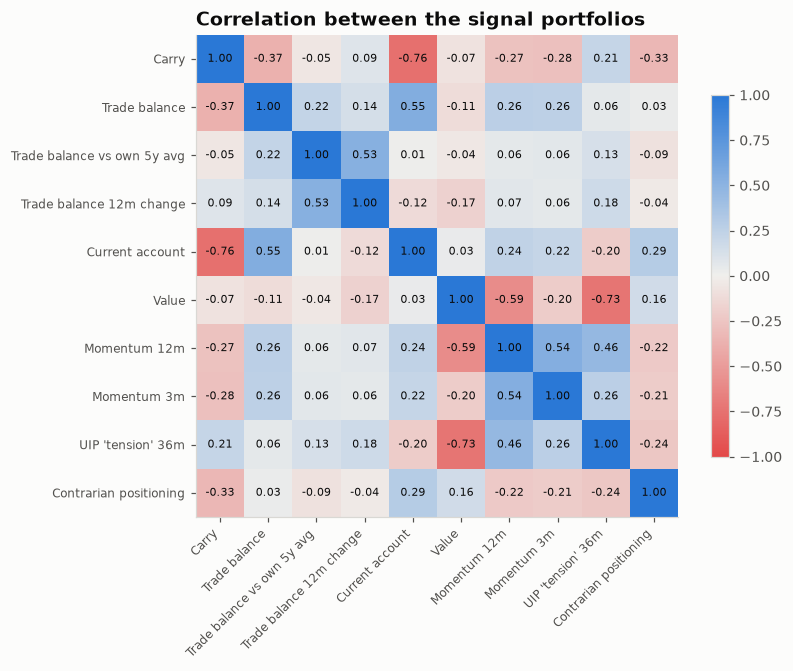

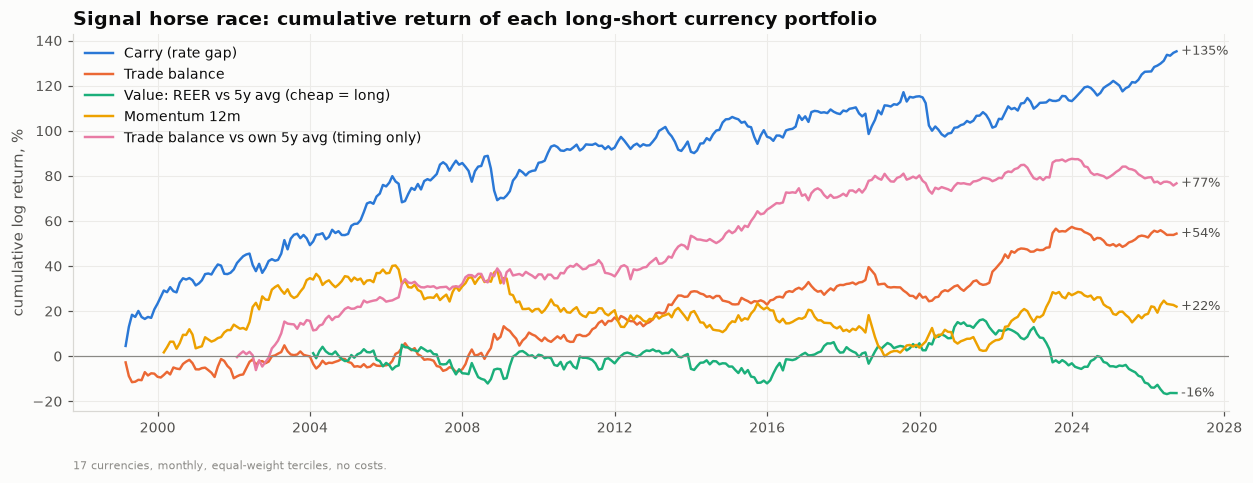

In [21]:
def hml(signal, q=1/3, min_n=6, cols=None):
    s = signal if cols is None else signal[cols]
    r = s.rank(axis=1, pct=True); fwd = rx[s.columns].shift(-1)
    out = fwd[r > 1 - q].mean(axis=1) - fwd[r <= q].mean(axis=1)
    out[s.notna().sum(axis=1) < min_n] = np.nan
    return out.shift(1).dropna()

reer_all = P["reer"]
signals = {
    "Carry (rate gap)": carry,
    "Trade balance": tb,
    "Trade balance vs own 5y avg (timing only)": tb - tb.rolling(60, min_periods=36).mean(),
    "Trade balance 12m change": tb.diff(12),
    "Current account": ca,
    "Value: REER vs 5y avg (cheap = long)": -np.log(reer_all / reer_all.rolling(60).mean()),
    "Momentum 12m": -ds.rolling(12).sum(),
    "Momentum 3m": -ds.rolling(3).sum(),
    "UIP 'tension' 36m (cum. deviation)": rx.rolling(36).sum(),
    "Contrarian positioning (CFTC)": -pos,
}
H = {k: hml(v) for k, v in signals.items()}
race = fx.perf_table(H)[["Ann. return %", "Ann. vol %", "Sharpe", "Skew", "Max drawdown %", "Months"]]
race["Ret 2000-12 %"] = [1200 * H[k][:"2012"].mean() for k in race.index]
race["Ret 2013-26 %"] = [1200 * H[k]["2013":].mean() for k in race.index]
race["t-stat"] = [H[k].mean() / H[k].std() * np.sqrt(len(H[k])) for k in race.index]
print("Long top-third / short bottom-third of currencies by each signal, rebalanced monthly, no costs:")
display(race.sort_values("Sharpe", ascending=False))

Hdf = pd.DataFrame(H).dropna()
cm = Hdf.corr()
fig, ax = plt.subplots(figsize=(7.8, 6.2))
im = ax.imshow(cm, cmap=DIVERGING, vmin=-1, vmax=1)
ax.set_xticks(range(len(cm))); ax.set_yticks(range(len(cm)))
short = [k.split(" (")[0].split(":")[0] for k in cm.index]
ax.set_xticklabels(short, rotation=45, ha="right", fontsize=8); ax.set_yticklabels(short, fontsize=8); ax.grid(False)
for i in range(len(cm)):
    for j in range(len(cm)):
        ax.text(j, i, f"{cm.iloc[i, j]:.2f}", ha="center", va="center", fontsize=7.5, color=INK)
ax.set_title("Correlation between the signal portfolios"); fig.colorbar(im, ax=ax, shrink=0.75)
fig.tight_layout(); fx.save(fig, "05e_signal_correlations"); plt.show()

fig, ax = plt.subplots(figsize=(11.5, 4.5))
for k, col in zip(["Carry (rate gap)", "Trade balance", "Value: REER vs 5y avg (cheap = long)", "Momentum 12m", "Trade balance vs own 5y avg (timing only)"], [BLUE, ORANGE, AQUA, YELLOW, MAGENTA]):
    s = 100 * H[k].cumsum(); ax.plot(s.index, s, color=col, label=k)
    ax.annotate(f"{s.iloc[-1]:+.0f}%", (s.index[-1], s.iloc[-1]), xytext=(3, 0), textcoords="offset points", fontsize=8.5, color=INK2, va="center")
ax.axhline(0, color=GRAY, lw=0.8); ax.legend(loc="upper left"); ax.set_ylabel("cumulative log return, %")
ax.set_title("Signal horse race: cumulative return of each long-short currency portfolio")
fx.source_note(ax, "17 currencies, monthly, equal-weight terciles, no costs.")
fig.tight_layout(); fx.save(fig, "05f_signal_horse_race"); plt.show()

#### 🔎 What this means

* **Carry is the strongest single signal** (Sharpe 0.61, t = 3.2), but it has faded: 6.8%/yr in 2000–12 vs 2.9%/yr in 2013–26.
* **Trade-balance signals are the only other ones that work, and consistently:** level (Sharpe 0.35), **vs. own 5-year average (0.52, t = 2.6)** and 12-month change (0.33). All are positive in both halves. The "vs own 5-year average" version only uses each country's *own* time variation, which rules out "it's just always long Brazil, short UK". An **improving** trade balance predicts currency outperformance.
* **Current account does *not* work** (−0.27). It sorts differently: it goes long low-yielders with big investment-income surpluses (CHF, JPY, SEK) and so fights carry. For FX returns, **goods trade matters, not total external income.** That matches the Japan story.
* **Failed signals:** 12m/3m momentum, REER value, the UIP-"tension" reversal (T4) and contrarian positioning (T5) all have Sharpe ≈ 0 or negative here. Momentum and value work in other studies over longer samples and more currencies. Our 17-currency, 27-year panel just doesn't show them, so I'd leave them out of the pitch.
* **Diversification:** carry and trade balance are **−0.32 correlated**, which is what makes combining them attractive.

### 5.7 Crash anatomy: what happens in carry's worst months?

The 10 worst months for the carry portfolio, and what the trade-balance portfolio did at the same time:


,Carry portfolio %,Trade-balance portfolio %,VIX change (pts)
Mar 2020,-9.91,-2.02,13.43
Oct 2008,-9.71,6.24,20.50
Aug 2018,-9.04,5.73,0.03
May 2006,-8.21,1.99,4.85
Sep 2008,-5.64,2.11,18.74
Jun 2002,-5.04,1.11,NaN
Mar 2008,-4.82,2.60,-0.93
Dec 2013,-4.55,2.07,0.02
Aug 2015,-4.41,0.90,16.31
Nov 2008,-4.33,-2.50,-4.05


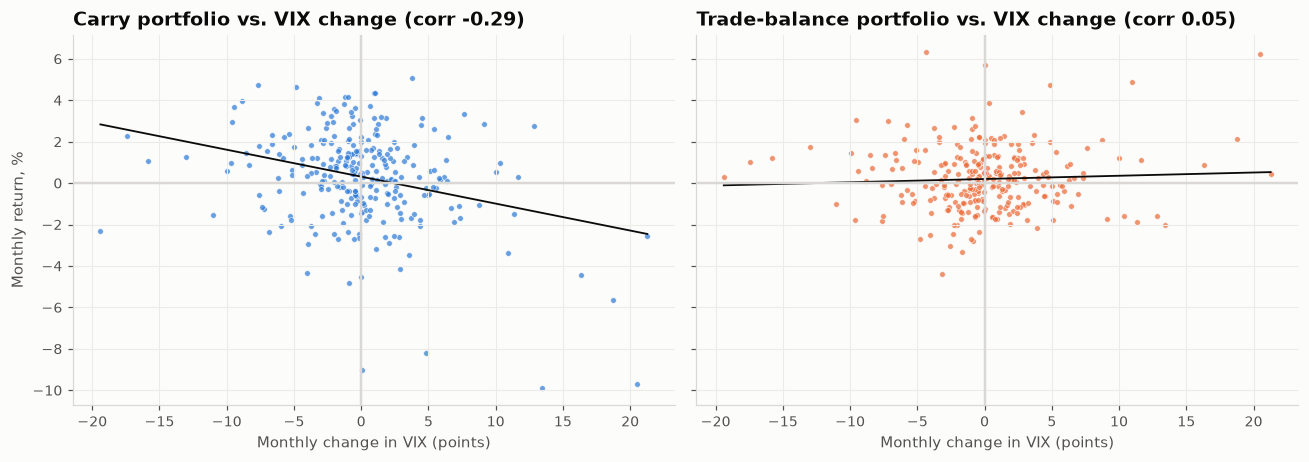

In [22]:
vix = fx.monthly_last(fx.fred("VIXCLS"))
dv = vix.diff().reindex(Hdf.index)
C, T = H["Carry (rate gap)"], H["Trade balance"]
worst = C.nsmallest(10).to_frame("Carry portfolio %").mul(100)
worst["Trade-balance portfolio %"] = 100 * T.reindex(worst.index)
worst["VIX change (pts)"] = dv.reindex(worst.index)
worst.index = worst.index.strftime("%b %Y")
print("The 10 worst months for the carry portfolio, and what the trade-balance portfolio did at the same time:")
display(worst)
fig, axes = plt.subplots(1, 2, figsize=(12, 4.3), sharey=True)
for ax, s, col, nm in [(axes[0], C, BLUE, "Carry portfolio"), (axes[1], T, ORANGE, "Trade-balance portfolio")]:
    d = pd.DataFrame({"dv": dv, "r": 100 * s}).dropna()
    ax.scatter(d.dv, d.r, s=14, color=col, alpha=0.7, edgecolor="white", linewidth=0.5)
    b = np.polyfit(d.dv, d.r, 1); xx = np.linspace(d.dv.min(), d.dv.max(), 10); ax.plot(xx, np.polyval(b, xx), color=INK, lw=1.2)
    ax.axhline(0, color=LIGHTGRAY); ax.axvline(0, color=LIGHTGRAY)
    ax.set_title(f"{nm} vs. VIX change (corr {d.dv.corr(d.r):.2f})"); ax.set_xlabel("Monthly change in VIX (points)")
axes[0].set_ylabel("Monthly return, %")
fig.tight_layout(); fx.save(fig, "05g_crash_risk_vs_vix"); plt.show()

#### 🔎 What this means

* Carry's worst months are the famous risk-off episodes (Mar 2020, Oct 2008, Aug 2018 Turkey, May 2006, Aug 2015 China devaluation). Its monthly correlation with ΔVIX is **−0.31**, so carry is effectively short volatility.
* **In 8 of carry's 10 worst months the trade-balance portfolio made money** (e.g. +6.2% in Oct 2008, +5.7% in Aug 2018), and its correlation with ΔVIX is ~0. The trade-balance signal naturally shorts the deficit currencies that crash hardest in risk-off.
* A simple VIX filter (exit carry when VIX is in its top 20% vs. the past 10 years) was tried in exploratory work. It cut drawdowns but cut returns more (Sharpe 0.61 → 0.51), so it's left out. The trade-balance leg is a better "hedge" than a timing filter.

---
## 6. Strategy design & backtests
Candidates, all monthly-rebalanced and **net of assumed costs** (G10 4bp / EM 12bp per unit traded, plus a monthly forward-roll cost):

* **A. Carry** — long top-third rate gap, short bottom-third (the classic benchmark).
* **B. Trade balance** — long top-third net exporters, short bottom-third net importers.
* **C. 50/50 blend of A and B** — the "carry + external balance" idea.
* **D. Composite** — rank on z(carry) + z(trade balance).
* **E/F. G10-only** versions — what a retail trader can realistically execute with CME futures.
* **G. Long-only EM carry** — buy the 3 highest-yielders vs USD (what most retail "carry" products do).

In [23]:
G10 = [c for c in spot if fx.U[c].group == "G10"]
COST = pd.Series({c: (4.0 if fx.U[c].group == "G10" else 12.0) for c in spot})   # bps per unit traded (one way)
ROLL = pd.Series({c: (0.5 if fx.U[c].group == "G10" else 2.0) for c in spot})    # bps per month per unit held (forward roll)

def tercile_w(signal, q=1/3, min_n=6):
    r = signal.rank(axis=1, pct=True)
    lo, sh = (r > 1 - q).astype(float), (r <= q).astype(float)
    w = lo.div(lo.sum(1), axis=0) - sh.div(sh.sum(1), axis=0)
    w[signal.notna().sum(axis=1) < min_n] = 0
    return w.fillna(0)

def zx(df):
    return df.sub(df.mean(1), axis=0).div(df.std(1), axis=0)

def run(w, start="2000-01-31"):
    w = w.reindex(columns=spot.columns, fill_value=0)[start:]
    gross = (w.shift(1) * rx[w.columns].reindex(w.index).fillna(0)).sum(axis=1)
    turnover = (w - w.shift(1).fillna(0)).abs()
    cost = (turnover * COST).sum(axis=1).shift(1).fillna(0) / 1e4 + (w.shift(1).abs() * ROLL).sum(axis=1) / 1e4
    return (gross - cost).iloc[1:], turnover.sum(axis=1).mean() * 12

W = {
    "A. Carry (17 ccy)": tercile_w(carry),
    "B. Trade balance (17 ccy)": tercile_w(tb),
    "C. 50/50 blend A+B": 0.5 * tercile_w(carry) + 0.5 * tercile_w(tb),
    "D. Composite z(carry)+z(trade)": tercile_w(zx(carry) + zx(tb)),
    "E. Carry, G10 only": tercile_w(carry[G10]),
    "F. 50/50 blend, G10 only": 0.5 * tercile_w(carry[G10]) + 0.5 * tercile_w(tb[G10]),
    "G. Long-only: top-3 carry vs USD": (lambda r: r.div(r.sum(1), axis=0).fillna(0))((carry.rank(axis=1, ascending=False) <= 3).astype(float)),
    # H was added AFTER seeing section 5.6 (post-hoc) - treat as exploratory, not as confirmed
    "H*. 50/50 carry + trade-vs-own-5y-avg (post-hoc)": 0.5 * tercile_w(carry) + 0.5 * tercile_w(tb - tb.rolling(60, min_periods=36).mean()),
}
R, TURN = {}, {}
for k, w in W.items():
    R[k], TURN[k] = run(w)
perf = fx.perf_table(R)[["Ann. return %", "Ann. vol %", "Sharpe", "Skew", "Worst month %", "Max drawdown %", "Hit rate %"]]
perf["Sharpe 2000-12"] = [fx.perf(R[k][:"2012"])["Sharpe"] for k in perf.index]
perf["Sharpe 2013-26"] = [fx.perf(R[k]["2013":])["Sharpe"] for k in perf.index]
perf["Sharpe last 5y"] = [fx.perf(R[k][R[k].index[-1] - pd.DateOffset(years=5):])["Sharpe"] for k in perf.index]
perf["Turnover x/yr"] = pd.Series(TURN)
print("Net of assumed costs (G10 4bp / EM 12bp per trade + monthly forward-roll cost). Monthly rebalance.")
perf

Net of assumed costs (G10 4bp / EM 12bp per trade + monthly forward-roll cost). Monthly rebalance.


,Ann. return %,Ann. vol %,Sharpe,Skew,Worst month %,Max drawdown %,Hit rate %,Sharpe 2000-12,Sharpe 2013-26,Sharpe last 5y,Turnover x/yr
A. Carry (17 ccy),3.37,7.68,0.44,-1.06,-9.93,-18.19,60.94,0.53,0.34,0.92,1.22
B. Trade balance (17 ccy),2.21,5.31,0.42,0.65,-4.44,-14.68,53.12,0.35,0.50,0.82,1.30
C. 50/50 blend A+B,2.92,3.97,0.73,-0.65,-5.99,-10.42,60.94,0.79,0.68,1.40,1.21
D. Composite z(carry)+z(trade),3.65,6.53,0.56,-0.94,-8.89,-17.10,60.31,0.65,0.46,1.18,1.59
"E. Carry, G10 only",2.84,7.09,0.40,-0.80,-11.22,-28.23,57.50,0.55,0.22,0.66,1.18
"F. 50/50 blend, G10 only",1.68,3.58,0.47,-0.28,-4.24,-8.51,58.44,0.63,0.31,0.85,1.20
G. Long-only: top-3 carry vs USD,4.74,11.08,0.43,-1.17,-14.98,-30.78,63.12,0.77,0.09,0.50,0.91
H*. 50/50 carry + trade-vs-own-5y-avg (post-hoc),2.87,4.78,0.60,-0.65,-6.59,-12.63,60.00,0.70,0.50,0.56,2.04


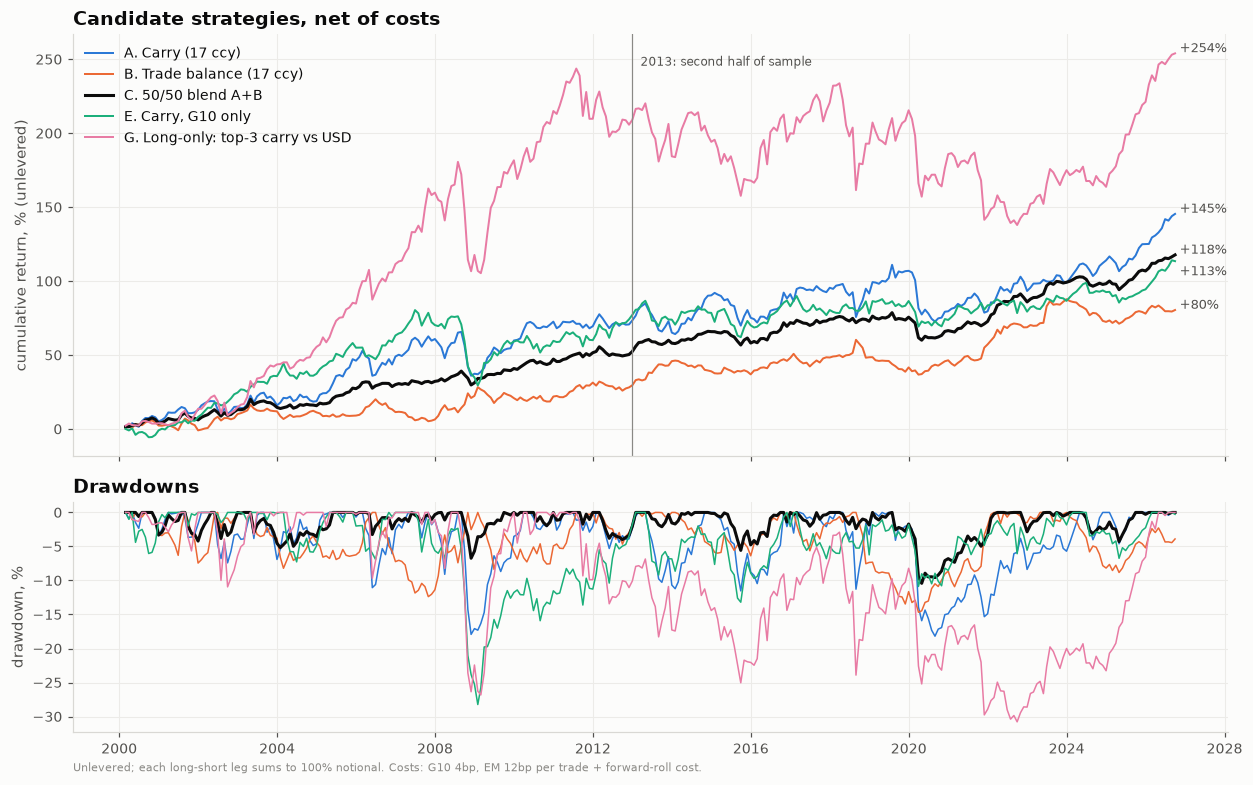

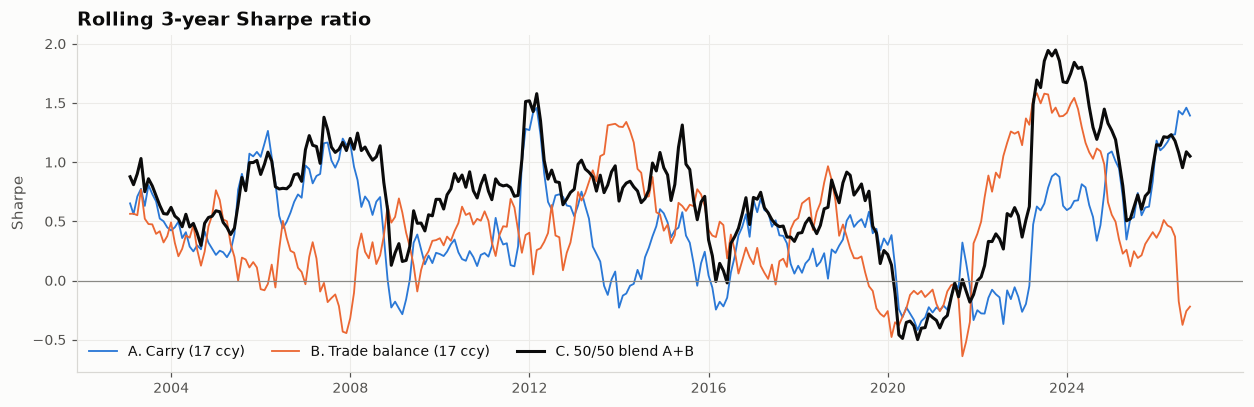

In [24]:
show = ["A. Carry (17 ccy)", "B. Trade balance (17 ccy)", "C. 50/50 blend A+B", "E. Carry, G10 only", "G. Long-only: top-3 carry vs USD"]
cols = [BLUE, ORANGE, INK, AQUA, MAGENTA]
fig, (a1, a2) = plt.subplots(2, 1, figsize=(11.5, 7.2), sharex=True, gridspec_kw={"height_ratios": [2.2, 1.2]})
for k, col in zip(show, cols):
    s = 100 * (np.exp(R[k].cumsum()) - 1)
    a1.plot(s.index, s, color=col, lw=2.0 if k.startswith("C.") else 1.3, label=k)
    a1.annotate(f"{s.iloc[-1]:+.0f}%", (s.index[-1], s.iloc[-1]), xytext=(3, -7 if k.startswith("E.") else 3), textcoords="offset points", fontsize=8.5, color=INK2, va="center")
    eq = R[k].cumsum(); dd = 100 * (np.exp(eq - eq.cummax()) - 1)
    a2.plot(dd.index, dd, color=col, lw=2.0 if k.startswith("C.") else 1.0)
a1.axvline(pd.Timestamp("2013-01-01"), color=GRAY, lw=0.8); a1.annotate("  2013: second half of sample", (pd.Timestamp("2013-01-01"), a1.get_ylim()[1] * 0.92), fontsize=8, color=INK2)
a1.set_ylabel("cumulative return, % (unlevered)"); a1.legend(loc="upper left"); a1.set_title("Candidate strategies, net of costs")
a2.set_ylabel("drawdown, %"); a2.set_title("Drawdowns")
fx.source_note(a2, "Unlevered; each long-short leg sums to 100% notional. Costs: G10 4bp, EM 12bp per trade + forward-roll cost.")
fig.tight_layout(); fx.save(fig, "06a_strategy_backtests"); plt.show()

roll = pd.DataFrame({k: R[k].rolling(36).mean() / R[k].rolling(36).std() * np.sqrt(12) for k in ["A. Carry (17 ccy)", "B. Trade balance (17 ccy)", "C. 50/50 blend A+B"]})
fig, ax = plt.subplots(figsize=(11.5, 3.8))
for k, col in zip(roll, [BLUE, ORANGE, INK]): ax.plot(roll.index, roll[k], color=col, lw=2.0 if k.startswith("C.") else 1.2, label=k)
ax.axhline(0, color=GRAY, lw=0.8); ax.legend(loc="lower left", ncol=3); ax.set_title("Rolling 3-year Sharpe ratio"); ax.set_ylabel("Sharpe")
fig.tight_layout(); fx.save(fig, "06b_rolling_sharpe"); plt.show()

#### 🔎 What this means

* **C (50/50 carry + trade balance) is the standout on risk-adjusted terms:** Sharpe **0.73** net of costs vs 0.44 for carry alone, max drawdown **−10%** vs −18%, worst month −6% vs −10%. It also holds up out of sample: **0.79 (2000–12) → 0.68 (2013–26)**, while carry alone decayed from 0.53 to 0.34.
* **Returns are small unlevered** (~2.9%/yr at 4% vol). To be interesting you'd **scale to a volatility target** (e.g. 8–10% vol ≈ 2–2.5× notional → roughly 6–7%/yr before financing). Leverage multiplies the tail risk too, so the −10% max drawdown becomes ~−25%.
* **D (single composite score)** is worse than the 50/50 blend. Keeping the two signals as separate sleeves diversifies better than merging them.
* **G (long-only EM carry)**, what most retail "carry" products do, had the highest raw return but **Sharpe 0.09 since 2013** and a −31% drawdown. It's mostly a bet on EM vs the dollar.
* **H\*** (the post-hoc "trade vs own history" variant) nets Sharpe 0.60, *below* C once its higher turnover is costed. Good news for honesty: the pre-specified strategy wins.
* **Last 5 years have been unusually good** for all versions (Sharpe 0.9–1.4), because of the high-rate era. Don't extrapolate that.

### 6.2 Robustness and holdings

In [25]:
grid = {}
P4 = fx.build_panel(trade_lag=4)
for q in (0.25, 1 / 3, 0.5):
    for reb in (1, 3):
        for lag_nm, tbx in [("trade lag 2m", tb), ("trade lag 4m", P4["trade"])]:
            wA, wB = tercile_w(carry, q=q), tercile_w(tbx, q=q)
            if reb == 3:
                wA = wA.iloc[::3].reindex(wA.index).ffill(); wB = wB.iloc[::3].reindex(wB.index).ffill()
            ra, _ = run(wA); rc, _ = run(0.5 * wA + 0.5 * wB)
            grid[(f"top/bottom {q:.0%}", f"rebalance every {reb}m", lag_nm)] = {"Carry Sharpe": fx.perf(ra)["Sharpe"], "Blend Sharpe": fx.perf(rc)["Sharpe"],
                                                                                "Blend max DD %": fx.perf(rc)["Max drawdown %"]}
print("Does the result survive reasonable changes to the recipe? (net Sharpe ratios)")
pd.DataFrame(grid).T

Does the result survive reasonable changes to the recipe? (net Sharpe ratios)


Carry Sharpe  Blend Sharpe  Blend max DD %
top/bottom 25% rebalance every 1m trade lag 2m          0.44          0.78          -11.20
                                  trade lag 4m          0.44          0.73           -9.01
               rebalance every 3m trade lag 2m          0.45          0.79           -9.77
                                  trade lag 4m          0.45          0.76           -9.77
top/bottom 33% rebalance every 1m trade lag 2m          0.44          0.73          -10.42
                                  trade lag 4m          0.44          0.75          -10.58
               rebalance every 3m trade lag 2m          0.40          0.70           -9.69
                                  trade lag 4m          0.40          0.74           -9.61
top/bottom 50% rebalance every 1m trade lag 2m          0.48          0.66           -9.54
                                  trade lag 4m          0.48          0.69           -7.27
               rebalance every 3m trade lag 2m          0.44          0.61           -8.68
                                  trade lag 4m          0.44          0.72           -6.64

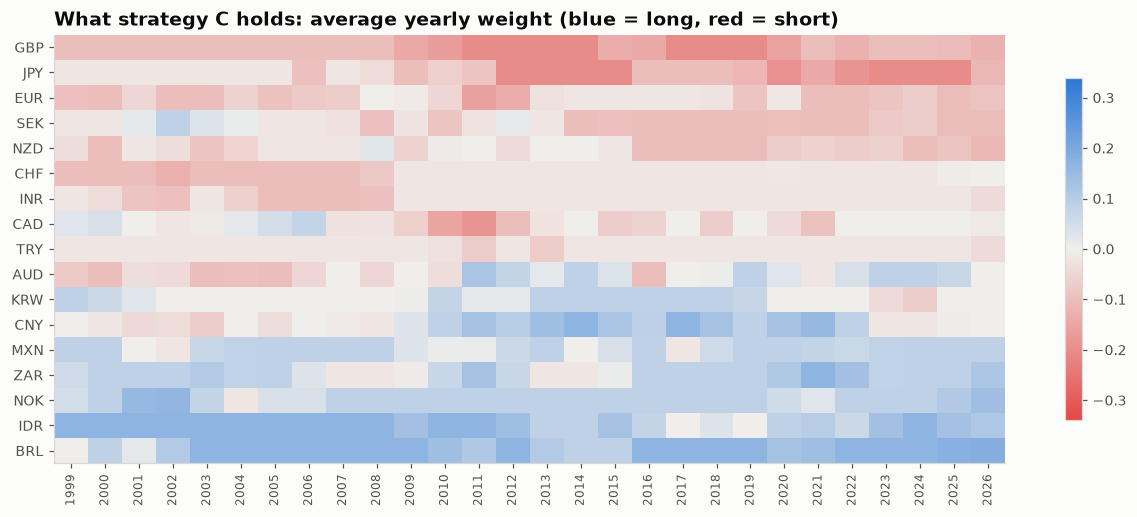

,% of months LONG,% of months SHORT,Avg weight,Weight now
GBP,0.00,100.00,-0.14,-0.12
JPY,0.00,100.00,-0.11,-0.10
EUR,0.00,82.88,-0.07,0.00
SEK,8.71,82.58,-0.05,-0.10
NZD,2.10,65.77,-0.05,-0.12
CHF,0.00,94.59,-0.05,0.00
INR,0.00,100.00,-0.04,-0.04
CAD,10.81,44.14,-0.03,-0.10
TRY,0.00,100.00,-0.02,-0.04
AUD,30.93,35.44,-0.00,0.00


In [26]:
wC = W["C. 50/50 blend A+B"]
hold = pd.DataFrame({"% of months LONG": 100 * (wC > 0.01).mean(), "% of months SHORT": 100 * (wC < -0.01).mean(),
                     "Avg weight": wC.mean(), "Weight now": wC.iloc[-1]}).sort_values("Avg weight")
fig, ax = plt.subplots(figsize=(11.5, 4.8))
wy = wC.resample("YE").mean().T.loc[hold.index]
im = ax.imshow(wy.values, aspect="auto", cmap=DIVERGING, vmin=-0.34, vmax=0.34)
ax.set_yticks(range(len(wy))); ax.set_yticklabels(wy.index); ax.set_xticks(range(len(wy.columns))); ax.set_xticklabels([d.year for d in wy.columns], rotation=90, fontsize=8)
ax.grid(False); ax.set_title("What strategy C holds: average yearly weight (blue = long, red = short)"); fig.colorbar(im, ax=ax, shrink=0.8)
fig.tight_layout(); fx.save(fig, "06c_strategy_c_holdings"); plt.show()
hold.round(2)

#### 🔎 What this means

* **Robustness:** C's Sharpe stays in a **0.61–0.79** band across long/short cut-offs (25/33/50%), rebalancing (monthly/quarterly) and trade-data lags (2 or 4 months). Carry alone stays at 0.40–0.48. The blend beats carry in all 12 variants, which suggests the result isn't an artifact of one parameter choice.
* **What it holds:** structurally **short GBP, JPY, INR, TRY** (100% of months) and usually NZD, SEK, CHF, EUR. Structurally **long BRL, IDR, NOK**, often ZAR and MXN. CNY/KRW/AUD rotate.
* **Heads-up for the pitch:** the model is **short INR**, the opposite of "long the defended net importer". INR's carry is middling, and its trade balance is the worst in the panel (−27% of trade). The strategy fits the Japan leg of the story (short yen) and treats India as the cautionary tale.
* Concentration risk: the long book leans on commodity-exporting EMs (BRL, NOK, IDR, ZAR). A global commodity bust is the scenario to stress-test.

### 6.3 Single-currency rules for JPY and INR
Simple, explainable rules a retail trader could follow for the two case-study currencies. Each filter is added one at a time so you can see what it contributes.

Single-currency rule: SHORT yen vs USD (no costs; monthly signals, act next month)


,Ann. return %,Ann. vol %,Sharpe,Skew,Worst month %,Max drawdown %,% months invested
Always short JPY,3.60,9.51,0.38,0.12,-7.44,-35.24,100.00
Short JPY if US-JP gap > 2%,2.71,6.42,0.42,0.06,-7.28,-23.92,42.06
Gap > 2% + USDJPY above 12m avg (trend),1.35,4.75,0.28,0.30,-6.32,-12.55,25.23
Gap > 2% + pause 3m after MoF buys yen,3.03,5.83,0.52,0.32,-7.28,-23.92,37.38
Gap > 2% + only in calm (low-vol) regimes,0.73,3.36,0.22,-0.44,-6.32,-16.46,19.63


Single-currency rule: LONG rupee vs USD (no costs)


,Ann. return %,Ann. vol %,Sharpe,Skew,Worst month %,Max drawdown %,% months invested
Always long INR,1.32,6.58,0.20,-0.26,-7.06,-20.92,100.00
Long if RBI reserves rose over last 3m,1.65,4.35,0.38,-0.13,-6.40,-10.05,70.40
Long if rupee vol below its median (calm),0.21,3.10,0.07,0.90,-3.55,-19.65,40.19
Long if India trade balance improved (6m),0.79,3.65,0.22,-2.08,-6.40,-14.63,38.01
Long if reserves rising AND calm,0.25,1.98,0.13,-1.21,-3.55,-12.00,26.17


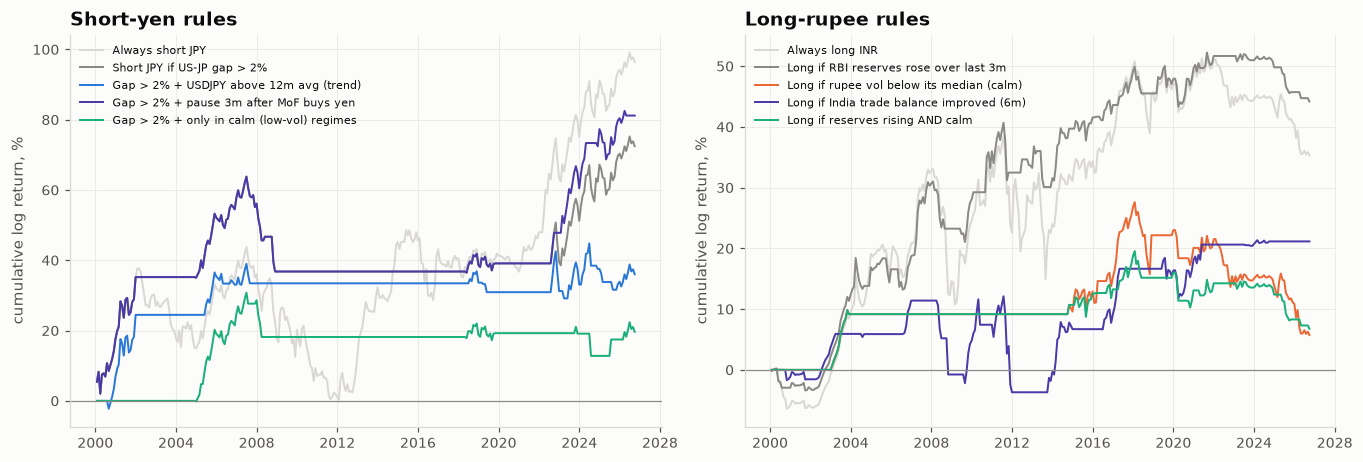

In [27]:
gapj = (P["us_rate"] - P["rate"]["JPY"]) / 100
short_jpy = -rx["JPY"]
trend_up = (spot["JPY"] > spot["JPY"].rolling(12).mean())
buy_ops_m = yen_ops[yen_ops.direction == "buy JPY"].set_index("date").yen_tn.resample("ME").sum().reindex(spot.index).fillna(0)
cooldown = buy_ops_m.rolling(3, min_periods=1).max() > 0
volj = (-ds["JPY"]).rolling(6).std() * np.sqrt(12)
calm = volj < volj.expanding(36).median()
rules = {"Always short JPY": pd.Series(True, index=spot.index),
         "Short JPY if US-JP gap > 2%": gapj > 0.02,
         "Gap > 2% + USDJPY above 12m avg (trend)": (gapj > 0.02) & trend_up,
         "Gap > 2% + pause 3m after MoF buys yen": (gapj > 0.02) & ~cooldown,
         "Gap > 2% + only in calm (low-vol) regimes": (gapj > 0.02) & calm}
JR = {k: (v.astype(float).shift(1) * short_jpy).dropna()["2000":] for k, v in rules.items()}
jt = fx.perf_table(JR)[["Ann. return %", "Ann. vol %", "Sharpe", "Skew", "Worst month %", "Max drawdown %"]]
jt["% months invested"] = [100 * rules[k].shift(1)["2000":].mean() for k in jt.index]
print("Single-currency rule: SHORT yen vs USD (no costs; monthly signals, act next month)"); display(jt)

res_in = P["reserves"]["INR"]
long_inr = rx["INR"]
volr = long_inr.rolling(12).std()
irules = {"Always long INR": pd.Series(True, index=spot.index),
          "Long if RBI reserves rose over last 3m": np.log(res_in).diff(3) > 0,
          "Long if rupee vol below its median (calm)": volr < volr.expanding(36).median(),
          "Long if India trade balance improved (6m)": tb["INR"].diff(6) > 0,
          "Long if reserves rising AND calm": (np.log(res_in).diff(3) > 0) & (volr < volr.expanding(36).median())}
IR = {k: (v.astype(float).shift(1) * long_inr).dropna()["2000":] for k, v in irules.items()}
it = fx.perf_table(IR)[["Ann. return %", "Ann. vol %", "Sharpe", "Skew", "Worst month %", "Max drawdown %"]]
it["% months invested"] = [100 * irules[k].shift(1)["2000":].mean() for k in it.index]
print("Single-currency rule: LONG rupee vs USD (no costs)"); display(it)

fig, (a1, a2) = plt.subplots(1, 2, figsize=(12.5, 4.3))
for ax, D, base_col in [(a1, JR, BLUE), (a2, IR, ORANGE)]:
    for (k, s), col in zip(D.items(), [LIGHTGRAY, GRAY, base_col, VIOLET, AQUA]):
        c = 100 * s.cumsum(); ax.plot(c.index, c, color=col, lw=1.3, label=k)
    ax.axhline(0, color=GRAY, lw=0.8); ax.legend(loc="upper left", fontsize=7.5); ax.set_ylabel("cumulative log return, %")
a1.set_title("Short-yen rules"); a2.set_title("Long-rupee rules")
fig.tight_layout(); fx.save(fig, "06d_single_currency_rules"); plt.show()

#### 🔎 What this means

**Short-yen rules** (small samples, no costs, so treat as illustrative):
* *Always short JPY* made 3.6%/yr but with a **−35%** drawdown (2007–12).
* Only shorting when the **US–Japan gap > 2%** keeps most of the return (2.7%/yr) at lower vol (Sharpe 0.42, drawdown −24%). This is the most defensible rule: it's the carry logic itself.
* Adding **"pause 3 months after MoF buys yen"** lifts the Sharpe from 0.42 to **0.52** (3.0%/yr) by skipping the choppy post-intervention months. The max drawdown is unchanged (−24%; it comes from 2007–08, not from interventions). The evidence rests on the handful of 2022–26 episodes, so it's thin, but it's also the rule with the clearest economic logic.
* Trend (0.28) and low-vol (0.22) filters **hurt**. Don't add them.

**Long-rupee rules:**
* *Always long INR* made 1.3%/yr, Sharpe 0.20, drawdown −21%.
* **"Only when RBI reserves rose over the last 3 months"** raises the Sharpe to **0.38** and halves the drawdown (**−10%**), while staying invested 70% of the time. This is the cleanest "use the central bank's own behaviour" signal we found, and it follows directly from §4.3.
* Vol and trade-improvement filters don't help for INR on their own.

### 6.4 Retail implementation guide (for the "how would someone actually do this" slide)
| Question | Suggested answer (based on the evidence above) |
|---|---|
| **What to trade** | **Core:** strategy C/F, a basket long top-third / short bottom-third by (a) rate gap and (b) trade balance, 50/50. **Satellite:** short JPY vs USD when the US–JP gap > 2%, paused 3 months after MoF yen-buying (Sharpe 0.52 vs 0.38 always-short); long INR only while RBI reserves rose over the last 3 months (Sharpe 0.38 vs 0.20). |
| **Instruments** | **G10:** CME currency futures, including **micro** contracts for JPY, EUR, GBP, AUD, CAD, CHF (carry is embedded in the futures price, so no broker financing spread). **EM:** CME BRL/MXN/ZAR futures, or spot FX at a broker with competitive financing. **INR:** not practical for most US retail. Onshore/NDF access is limited and INR futures trade mainly on Indian exchanges (NSE / GIFT City); NRIs can use FCNR(B)/NRE deposits. *Verify current product availability before presenting.* |
| **Rebalancing** | Monthly (quarterly also works; §6.2). Use trade data with a 2-month lag, rates as of month-end. |
| **Sizing** | Volatility-target the whole book (e.g. 8% annualised) using trailing 6–12m realised vol; cap any single currency at ~20% of gross. |
| **Holding period / horizon** | Signals are slow; evaluate over **3–5 years**, not months. Carry had multi-year flat periods (2013–19). |
| **When it works best** | Stable or falling global volatility, wide cross-country rate dispersion, and trade balances that diverge clearly across countries. |
| **When to be careful** | Global risk-off (VIX spikes), commodity crashes (the long book is commodity-heavy), coordinated interventions (JPY), and the approach to an FCNR-style defence *without* a global tailwind (INR 2026). |
| **Costs that kill retail carry** | Broker financing spreads of 1–2%/yr on spot FX can wipe out a 2–3% carry. Prefer futures or brokers that pass through benchmark rates. |
| **Realistic expectations** | Unlevered ~3%/yr at ~4% vol. At 8–10% vol, perhaps 5–7%/yr before fees, with drawdowns of ~20–25% in a 2008-type year. |

---
## 7. Where things stand now (September 2026)

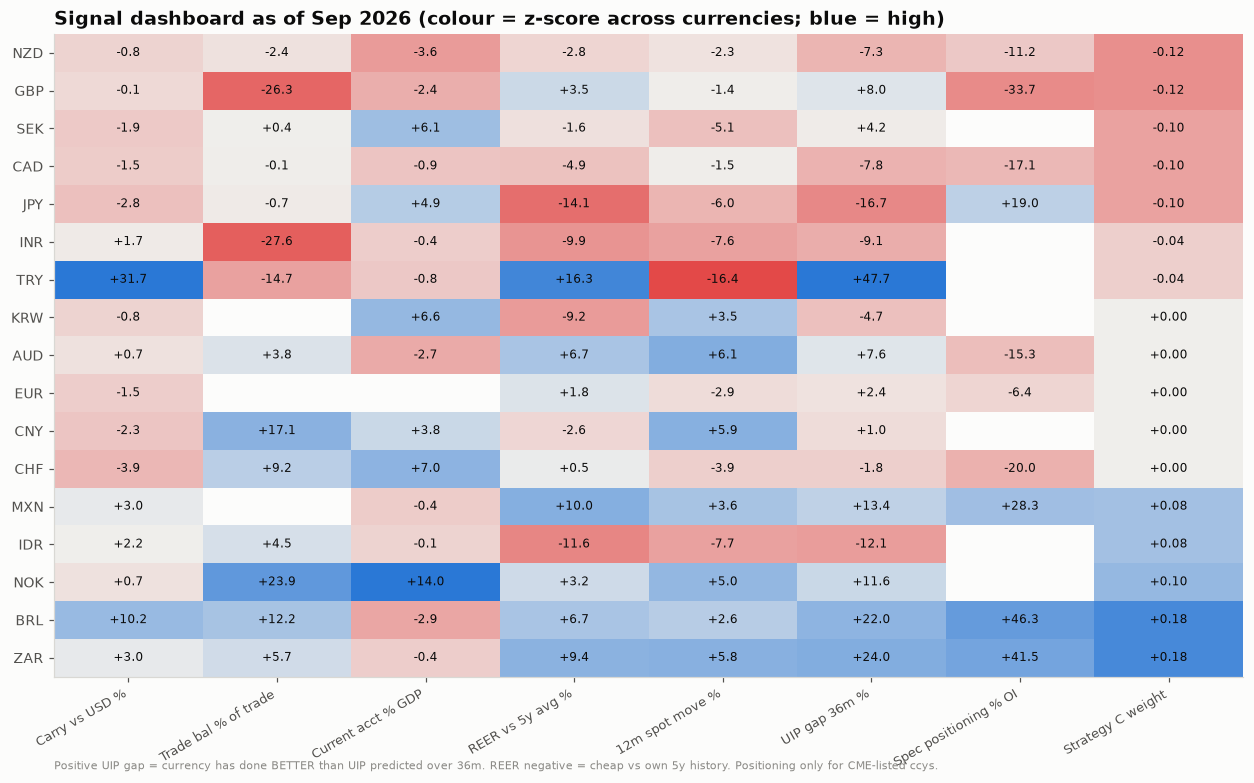

,Carry vs USD %,Trade bal % of trade,Current acct % GDP,REER vs 5y avg %,12m spot move %,UIP gap 36m %,Spec positioning % OI,Strategy C weight
NZD,-0.84,-2.39,-3.62,-2.79,-2.30,-7.33,-11.23,-0.12
GBP,-0.09,-26.28,-2.43,3.53,-1.45,8.03,-33.71,-0.12
SEK,-1.85,0.40,6.06,-1.63,-5.06,4.21,NaN,-0.10
CAD,-1.54,-0.13,-0.95,-4.92,-1.52,-7.78,-17.10,-0.10
JPY,-2.84,-0.66,4.86,-14.08,-6.04,-16.74,19.01,-0.10
INR,1.68,-27.58,-0.42,-9.92,-7.62,-9.08,NaN,-0.04
TRY,31.68,-14.74,-0.77,16.30,-16.42,47.74,NaN,-0.04
KRW,-0.85,NaN,6.57,-9.20,3.49,-4.74,NaN,0.00
AUD,0.69,3.82,-2.68,6.67,6.14,7.60,-15.27,0.00
EUR,-1.45,NaN,NaN,1.83,-2.90,2.36,-6.37,0.00


In [28]:
asof = spot.index[-1]
def latest(df):
    return df.ffill(limit=4).iloc[-1]
snap = pd.DataFrame({
    "Carry vs USD %": 100 * latest(carry),
    "Trade bal % of trade": latest(tb),
    "Current acct % GDP": latest(ca),
    "REER vs 5y avg %": 100 * latest(np.log(P["reer"] / P["reer"].rolling(60).mean())),
    "12m spot move %": 100 * latest(-ds.rolling(12).sum()),
    "UIP gap 36m %": 100 * latest(rx.rolling(36).sum()),
    "Spec positioning % OI": latest(pos),
    "Strategy C weight": W["C. 50/50 blend A+B"].iloc[-1],
}).sort_values("Strategy C weight")
Z = snap.apply(lambda c: (c - c.mean()) / c.std())
fig, ax = plt.subplots(figsize=(11.5, 7.2))
ax.imshow(Z.values.astype(float), cmap=DIVERGING, vmin=-2.2, vmax=2.2, aspect="auto")
for i in range(Z.shape[0]):
    for j in range(Z.shape[1]):
        v = snap.iloc[i, j]
        if pd.notna(v): ax.text(j, i, f"{v:+.2f}" if j == Z.shape[1] - 1 else f"{v:+.1f}", ha="center", va="center", fontsize=8, color=INK)
ax.set_xticks(range(Z.shape[1])); ax.set_xticklabels(Z.columns, rotation=30, ha="right", fontsize=8.5)
ax.set_yticks(range(Z.shape[0])); ax.set_yticklabels(Z.index); ax.grid(False)
ax.set_title(f"Signal dashboard as of {asof:%b %Y} (colour = z-score across currencies; blue = high)")
fx.source_note(ax, "Positive UIP gap = currency has done BETTER than UIP predicted over 36m. REER negative = cheap vs own 5y history. Positioning only for CME-listed ccys.")
fig.tight_layout(); fx.save(fig, "07a_signal_dashboard_now"); plt.show()
snap.round(2)

#### 🔎 What this means

* **Strategy C today:** **long BRL, ZAR (+0.18 each), NOK (+0.10), IDR, MXN (+0.08)**; **short NZD, GBP (−0.12), SEK, CAD, JPY (−0.10), INR, TRY (−0.04)**. (EUR, KRW and MXN have stale OECD trade data, so they sit only in the carry sleeve.)
* **Yen:** carry still says short (gap −2.8pp). But the yen is **14% cheap vs its own 5-year average**, has **undershot its UIP path by ~17% over 36 months** (the largest shortfall in the panel), and **speculators are now net long** (+19% OI). Two rounds of intervention in 2026 (the second coordinated with the US) add event risk. **The carry case is intact; the asymmetry has worsened.** The satellite rule (gap > 2%, paused 3 months after MoF yen-buying) is **flat through October 2026** and re-enters in November if the gap is still > 2%.
* **Rupee — the signals disagree, which is itself informative.** The cross-sectional model is **short INR**: worst trade balance in the panel (−28% of trade), a thin rate gap (+1.7pp), and 7.6% weaker over 12 months. It is also **~10% cheap** in REER terms. Meanwhile the **RBI-reserves filter has just switched ON**: July reserves jumped from $566bn to $588bn. But that jump is largely **FCNR(B) swap inflows**, i.e. borrowed dollars the RBI owes back in 3–5 years, not organic strength. I'd treat it as a weak "on" signal and watch whether reserves keep rising once the window's inflows stop (August–October prints).

---
## 8. Synthesis

### 8.1 Theory scorecard
| # | Theory | Verdict | Key evidence |
|---|---|---|---|
| T0 | UIP fails (baseline) | ✅ **Supported** | Pooled β 0.25 (t = −5.1 vs 1); USDJPY 96% above UIP path since 2012 |
| T1 | Net importers' high rates are *defended*, so carry pays more on them | ❌ **Refuted (reversed)** | Net-importer β 0.41 vs exporter −0.20; high-carry importers earn +0.6% vs +3.0%, skew −1.40 vs −0.44; robust across 13/14 variants |
| T1 (Japan) | Trade position sets the **direction** of intervention | ✅ **Supported (1 country)** | All yen-selling in surplus years (1993–2011); all yen-buying in deficit years (2022–26); CA stayed positive throughout |
| T1b | Net importers defend against depreciation more | ⚠️ **Mixed** | Strong for INR (−0.50 corr); cross-section corr +0.26: defenders are managed regimes (CNY, JPY, INR, KRW) regardless of trade |
| T2 | Managed/high carry = "stairs up, elevator down" | ✅ **Supported** | Carry vs skew −0.87; INR vol 6.7% with big losing years; carry corr with ΔVIX −0.31 |
| T3 | Intervention sticks only with a policy tailwind | ❌ **Not supported (small n)** | Corr −0.44 across 28 episodes; likely confounded |
| T4 | UIP "tension" predicts reversal | ❌ **Not supported** | Sharpe −0.04 (36m); −0.05 (60m) |
| T5 | Crowded positioning predicts reversal | ❌ **Not supported** | Contrarian Sharpe −0.16; most-short yen quintile followed by *more* weakness |
| T6 | Interventions cluster at fixed round numbers | ⚠️ **Partly** | Triggers drift upward each cycle (145 → 160 → 164); "new multi-decade high" fits better than a fixed line |
| T7 | Cheap currencies mean-revert | ⚠️ **Not at 1–12m horizons** | REER-value Sharpe ≈ −0.1; yen at record cheapness and still falling |
| T8 | FCNR(B) windows mark rupee bottoms | ⚠️ **1 for 2 so far** | 2013: −12% USDINR a year later; 2026: flat so far |
| **New** | **Trade balance is a stand-alone FX signal and diversifies carry** | ✅ **Supported** | Sharpe 0.35–0.52 across three constructions, both halves; −0.32 corr with carry; positive in 8 of carry's 10 worst months |

### 8.2 My interpretation
**The original idea contains the right ingredients, combined the other way round.** We started from: *"rates imply drift, governments fight it, net importers are the ones fighting — trade that."* The data agrees that (a) rate-implied drift doesn't happen reliably, (b) governments fight it, and (c) the trade position tells you which side they fight on. But **fighting doesn't make the net importer's currency a good buy.** Defence smooths the path and then fails in a crash, and deficit currencies end up depreciating roughly in line with their rate gap (β closer to 1). The profitable deviation from UIP is in the **surplus** high-yielders, which don't need their high rates to attract capital.

**So the investable version of the thesis is:**
> *Harvest the interest-rate gap only where the trade balance supports the currency; fund it with the currencies whose trade balance is deteriorating. When a net-importer's central bank starts spending reserves, that's a warning, not a floor.*

This is a two-factor currency strategy, **carry + external balance**, where the second factor is both a return source and a crash hedge. It gives a clean story, a robust backtest (Sharpe ~0.7 net, both halves, 12 variants) and a direct link to the two case studies:
* **Japan** = the funding leg. Low rates, a goods-trade deficit and a cheap, heavily-shorted currency: the short-yen trade *worked* for a decade. Now intervention (including the rare US joint action) and positioning have made it riskier, which our satellite rule handles with a post-intervention pause.
* **India** = the cautionary tale. The team's archetype (high rate, net importer, defended) delivered the "stairs up, elevator down" profile. Its long-run return is barely positive, and the 2026 defence hasn't worked yet. The one thing that improved it was **following the central bank's reserves**: be long only while the RBI is *accumulating*, not defending.

**What I'm least sure about:** (1) the trade-balance signal partly overlaps with a commodity-exporter tilt (BRL, NOK, IDR, ZAR), even though the "vs own history" version suggests it's more than that; (2) the intervention analyses rest on a few dozen episodes from one country; (3) our carry proxy uses interbank rates, not forward points, which likely understates INR carry during stress (2026 hedging cost ~280–300bp vs a ~170bp rate gap).

### 8.3 Suggested presentation storyline (figures in `figures/`)
1. **Hook — "rates should predict FX, but…"** → `02_uip_vs_actual_jpy_inr.png` (yen 96% off its UIP path; rupee roughly on it).
2. **Governments fight the drift, and the trade balance says which way** → `03b_japan_trade_vs_intervention_direction.png`.
3. **Does fighting work?** → `03c_intervention_event_study.png` + `03e_2025_2026_closeup.png` (works for weeks; April 2026 failed; BoJ hikes weaken the yen) and `04e_fcnr_2013_vs_2026.png` (2013 worked with a Fed tailwind; 2026 hasn't).
4. **India = stairs up, elevator down** → `04b_inr_actual_vs_uip_by_year.png` + `04f_carry_decomposition_inr_jpy.png`.
5. **Test the thesis on 17 currencies — the twist** → `05c_two_by_two_carry_trade_balance.png` (net importers are the *worst* carry) + `05a_fama_betas.png`.
6. **The trade balance is its own signal and hedges carry** → `05f_signal_horse_race.png` + `05e_signal_correlations.png` + the worst-months table (§5.7).
7. **Strategy** → `06a_strategy_backtests.png` + `06b_rolling_sharpe.png` + robustness table (§6.2); rules and instruments from §6.4.
8. **Where we are now** → `07a_signal_dashboard_now.png`: long BRL/ZAR/NOK, short GBP/NZD/JPY/INR; the yen trade is paused post-intervention; INR signals conflict (reserves up on FCNR inflows, fundamentals weak).
9. **Risks & what would change our mind** → §8.4.

### 8.4 Caveats & limitations (please read before presenting numbers)
* **Carry proxy.** We use 3M interbank / call-money rates instead of actual forward points. Covered interest parity mostly holds for G10, but EM forwards (especially INR, TRY, BRL, IDR) can diverge a lot in stress, and onshore/offshore (NDF) markets differ. Real INR carry in 2026 was larger than our proxy.
* **Data gaps.** OECD trade data ends 2023 for the euro area and mid-2025 for Korea (these drop out of the trade signal). TRY and IDR spot come from Yahoo Finance (cleaned for bad ticks). Pre-2002 Japanese 3M rates are call-money rates.
* **Look-ahead control is approximate.** We lag trade by 2 months, reserves by 1, annual current account to April of the next year. Some data gets revised after first release; we use today's vintage.
* **Costs are stylised** (G10 4bp, EM 12bp per trade + roll). Retail spreads and financing can be much worse. Futures help.
* **Multiple testing.** We tried ~10 signals and ~8 strategies plus variants. C was specified before seeing strategy results, and its consistency across halves and variants is reassuring, but a Sharpe of 0.7 on ~27 years of data has wide error bars (roughly ±0.4).
* **Small event samples.** ~28 Japanese intervention episodes, 6 BoJ hikes, 2 FCNR windows. Treat those sections as case evidence, not statistics.
* **2026 intervention amounts** for 30–31 July are estimates from MoF's monthly total (¥15.4tn for 30 Jul–26 Aug) and press reports. Daily detail will appear in MoF's Q3 release (early November).
* **Regime risk.** The carry and trade-balance relationships held across 2000–2026, but that period includes zero-rate policy, QE and a commodity super-cycle. A different regime (e.g. a sustained dollar bear market) could change them.

### 8.5 Suggested next steps for the team
1. **Replace rate-gap carry with forward points** for G10 (e.g. from futures basis) and check the INR NDF vs onshore forward.
2. **Extend the universe** to ~30 currencies (PLN, HUF, CZK, CLP, COP, PHP, THB, MYR, ILS, SGD) to test the trade-balance result out of sample. This is the single best robustness check.
3. **Separate commodity from non-commodity exporters** to see how much of the trade signal is a commodity-cycle bet.
4. **Replicate with CME futures prices** (JPY, EUR, GBP, AUD, CAD, CHF, MXN, BRL, ZAR) to get a genuinely tradable retail backtest including roll.
5. **Monitor live:** MoF's Q3 intervention release (early Nov 2026), RBI weekly reserves (the INR filter), and the monthly strategy weights from §7.

### 8.6 References & sources
**Academic**
* Fama, E. (1984). "Forward and spot exchange rates." *Journal of Monetary Economics* — the forward premium puzzle.
* Lustig, H., Roussanov, N. & Verdelhan, A. (2011). "Common risk factors in currency markets." *Review of Financial Studies*.
* Brunnermeier, M., Nagel, S. & Pedersen, L. (2008). "Carry trades and currency crashes." *NBER Macroeconomics Annual*.
* Della Corte, P., Riddiough, S. & Sarno, L. (2016). "Currency premia and global imbalances." *Review of Financial Studies* — external-imbalance risk premium, closely related to our trade-balance signal.
* Menkhoff, L., Sarno, L., Schmeling, M. & Schrimpf, A. (2012). "Carry trades and global foreign exchange volatility." *Journal of Finance*.
* Asness, C., Moskowitz, T. & Pedersen, L. (2013). "Value and momentum everywhere." *Journal of Finance*.

**Data**: FRED (Federal Reserve H.10, OECD MEI, IMF IFS, BIS), Japan Ministry of Finance intervention records, CFTC Commitments of Traders, World Bank WDI, Yahoo Finance.

**2026 events (news)**
* CNBC — [U.S., Japan confirm coordinated yen intervention (3 Aug 2026)](https://www.cnbc.com/2026/08/03/yen-intervention-us-japan-trump-bessent-katayama.html); [U.S. Treasury intervenes to support yen (1 Aug 2026)](https://www.cnbc.com/2026/08/01/us-treasury-intervenes-to-support-yen-after-japan-steps-in-ft.html)
* Wikipedia — [2026 U.S.–Japan yen intervention](https://en.wikipedia.org/wiki/2026_U.S.%E2%80%93Japan_yen_intervention)
* Bloomberg — [BOJ data point to $34bn Japan FX intervention (3 Aug 2026)](https://www.bloomberg.com/news/articles/2026-08-03/boj-data-point-to-34-billion-japanese-fx-intervention-on-friday)
* CNBC — [BoJ raises rates to 1.25%, 31-year high (18 Sep 2026)](https://www.cnbc.com/2026/09/18/japan-raises-rates-30-year-high-yen-jgb.html); [BoJ hikes to 1% (16 Jun 2026)](https://www.cnbc.com/2026/06/16/boj-rate-hike-historic-inflation.html); [BoJ to 0.75% (19 Dec 2025)](https://www.cnbc.com/2025/12/19/bank-of-japan-boj-rate-cpi-inflation-takaichi-ueda.html)
* Business Standard — [RBI opens FCNR(B) swap window (9 Jun 2026)](https://www.business-standard.com/finance/news/rbi-opens-fcnr-b-swap-window-to-attract-foreign-currency-deposits-126060900723_1.html); [FCNR(B) window explained / early close (17 Aug 2026)](https://www.business-standard.com/finance/news/rbi-fcnr-b-window-nri-dollar-swap-deposit-scheme-deadline-forex-126081700609_1.html)
* Bloomberg — [RBI intervenes as rupee drops to record low (20 May 2026)](https://www.bloomberg.com/news/articles/2026-05-20/inr-usd-indian-central-bank-intervenes-as-rupee-drops-to-record-low)
* Japan MoF — [Foreign Exchange Intervention Operations](https://www.mof.go.jp/english/policy/international_policy/reference/feio/index.html)